In [5]:
!pip install streamlit
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy openpyxl

In [6]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    StratifiedGroupKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif
)

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
# ==========================================================
# DATASET UPLOAD
# ==========================================================

import os
import glob

uploaded_file_path = None

# ----------------------------------------------------------
# OPTION 1: Google Colab upload
# ----------------------------------------------------------

try:
    from google.colab import files

    print("Please select your dataset file.")

    uploaded = files.upload()

    if uploaded:
        uploaded_file_path = list(uploaded.keys())[0]
        print("\nFile uploaded successfully:")
        print(uploaded_file_path)

except ImportError:
    print("Google Colab upload is not available.")

Please select your dataset file.


Saving archive.zip to archive.zip

File uploaded successfully:
archive.zip


In [8]:
# ==========================================================
# LOAD DATASET
# ==========================================================

if uploaded_file_path is None:

    # Search common locations automatically
    possible_files = []

    search_locations = [
        ".",
        "/mnt/data",
        "/content"
    ]

    for location in search_locations:

        if os.path.exists(location):

            possible_files.extend(
                glob.glob(
                    os.path.join(location, "*.csv")
                )
            )

            possible_files.extend(
                glob.glob(
                    os.path.join(location, "*.data")
                )
            )

            possible_files.extend(
                glob.glob(
                    os.path.join(location, "*.txt")
                )
            )

    # Remove duplicates
    possible_files = list(
        dict.fromkeys(possible_files)
    )

    if len(possible_files) == 0:

        raise FileNotFoundError(
            """
            Dataset not found.

            Please upload the dataset using the upload
            cell above and run this cell again.
            """
        )

    print("Files found:")

    for i, file in enumerate(possible_files):

        print(
            f"{i}: {file}"
        )

    uploaded_file_path = possible_files[0]

    print(
        "\nAutomatically selected:",
        uploaded_file_path
    )


# ----------------------------------------------------------
# Read dataset
# ----------------------------------------------------------

try:

    df = pd.read_csv(
        uploaded_file_path
    )

except Exception:

    try:

        df = pd.read_csv(
            uploaded_file_path,
            encoding="latin1"
        )

    except Exception:

        df = pd.read_csv(
            uploaded_file_path,
            sep=",",
            encoding="latin1"
        )


print("\nDataset loaded successfully!")
print("--------------------------------")
print("File:", uploaded_file_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


Dataset loaded successfully!
--------------------------------
File: archive.zip
Rows: 195
Columns: 24


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [9]:
# ==========================================================
# DATASET INFORMATION
# ==========================================================

print("DATASET INFORMATION")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(
    df.dtypes.to_frame("Data Type")
)

print("\nFirst 10 Rows:")
display(
    df.head(10)
)

DATASET INFORMATION

Shape:
(195, 24)

Column Names:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Data Types:


,Data Type
name,object
MDVP:Fo(Hz),float64
MDVP:Fhi(Hz),float64
MDVP:Flo(Hz),float64
MDVP:Jitter(%),float64
MDVP:Jitter(Abs),float64
MDVP:RAP,float64
MDVP:PPQ,float64
Jitter:DDP,float64
MDVP:Shimmer,float64



First 10 Rows:


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
5,phon_R01_S01_6,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,...,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
6,phon_R01_S02_1,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,...,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
7,phon_R01_S02_2,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,...,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
8,phon_R01_S02_3,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,...,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
9,phon_R01_S02_4,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,...,0.04324,0.01022,21.862,1,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362


In [10]:
# ==========================================================
# DATA QUALITY ANALYSIS
# ==========================================================

print("DATA QUALITY ANALYSIS")
print("=" * 60)

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum()
    / len(df)
) * 100

quality_df = pd.DataFrame({

    "Feature":
        df.columns,

    "Missing_Values":
        missing_values.values,

    "Missing_Percentage":
        missing_percentage.values,

    "Unique_Values":
        [
            df[col].nunique()
            for col in df.columns
        ]

})

display(
    quality_df
)

print(
    "\nTotal duplicate rows:",
    df.duplicated().sum()
)

DATA QUALITY ANALYSIS


,Feature,Missing_Values,Missing_Percentage,Unique_Values
0,name,0,0.0,195
1,MDVP:Fo(Hz),0,0.0,195
2,MDVP:Fhi(Hz),0,0.0,195
3,MDVP:Flo(Hz),0,0.0,195
4,MDVP:Jitter(%),0,0.0,173
5,MDVP:Jitter(Abs),0,0.0,19
6,MDVP:RAP,0,0.0,155
7,MDVP:PPQ,0,0.0,165
8,Jitter:DDP,0,0.0,180
9,MDVP:Shimmer,0,0.0,188



Total duplicate rows: 0


In [11]:
# ==========================================================
# DATA CLEANING
# ==========================================================

df_clean = df.copy()

# Remove duplicate rows
duplicate_count = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates()

print(
    "Duplicate rows removed:",
    duplicate_count
)

# Display remaining shape
print(
    "Cleaned dataset shape:",
    df_clean.shape
)

Duplicate rows removed: 0
Cleaned dataset shape: (195, 24)


In [12]:
# ==========================================================
# TARGET VARIABLE
# ==========================================================

print("Available columns:")
print(df_clean.columns.tolist())

if "status" in df_clean.columns:

    target_column = "status"

else:

    print(
        "\nTarget column 'status' was not found."
    )

    target_column = input(
        "Enter the target column name: "
    )

print(
    "\nTarget column:",
    target_column
)

print("\nTarget distribution:")

display(
    df_clean[target_column]
    .value_counts()
    .to_frame("Count")
)

Available columns:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Target column: status

Target distribution:


,Count
status,
1,147
0,48


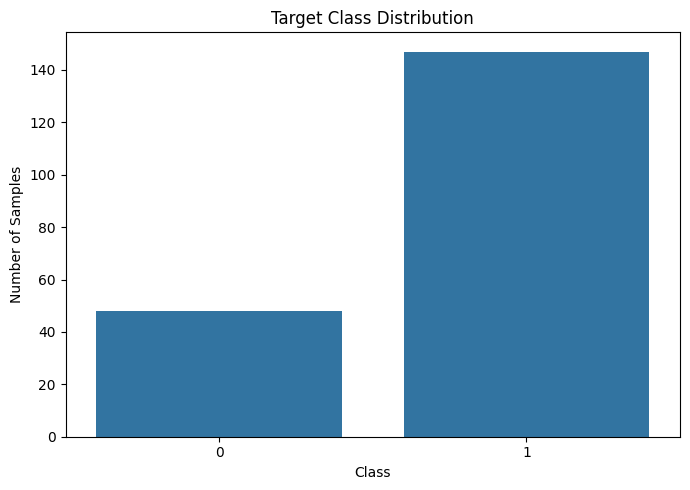

In [13]:
# ==========================================================
# CLASS DISTRIBUTION
# ==========================================================

class_counts = (
    df_clean[target_column]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=class_counts.index.astype(str),
    y=class_counts.values
)

plt.title(
    "Target Class Distribution"
)

plt.xlabel("Class")

plt.ylabel(
    "Number of Samples"
)

plt.tight_layout()

plt.show()

In [14]:
# ==========================================================
# FEATURES AND TARGET
# ==========================================================

drop_columns = [
    target_column
]

# The name column identifies the subject,
# but should not be used as a predictive feature.

if "name" in df_clean.columns:

    drop_columns.append("name")


X = df_clean.drop(
    columns=drop_columns
)

y = df_clean[target_column]


# Keep numerical features only

X = X.select_dtypes(
    include=np.number
)


print(
    "Number of samples:",
    X.shape[0]
)

print(
    "Number of numerical features:",
    X.shape[1]
)

print(
    "\nFeatures:"
)

print(
    X.columns.tolist()
)

Number of samples: 195
Number of numerical features: 22

Features:
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [15]:
# ==========================================================
# DESCRIPTIVE STATISTICS
# ==========================================================

descriptive_stats = X.describe().T

descriptive_stats["Variance"] = X.var()

descriptive_stats["Skewness"] = X.skew()

descriptive_stats["Kurtosis"] = X.kurtosis()

display(
    descriptive_stats
)

,count,mean,std,min,25%,50%,75%,max,Variance,Skewness,Kurtosis
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000,1.713137e+03,0.591737,-0.627898
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000,8.370703e+03,2.542146,7.627241
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000,1.894113e+03,1.217350,0.654615
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160,2.350440e-05,3.084946,12.030939
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260,1.212565e-09,2.649071,10.869043
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440,8.807685e-06,3.360708,14.213798
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580,7.611952e-06,3.073892,11.963922
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330,7.926954e-05,3.362058,14.224762
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080,3.555839e-04,1.666480,3.238308
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000,3.797716e-02,1.999389,5.128193


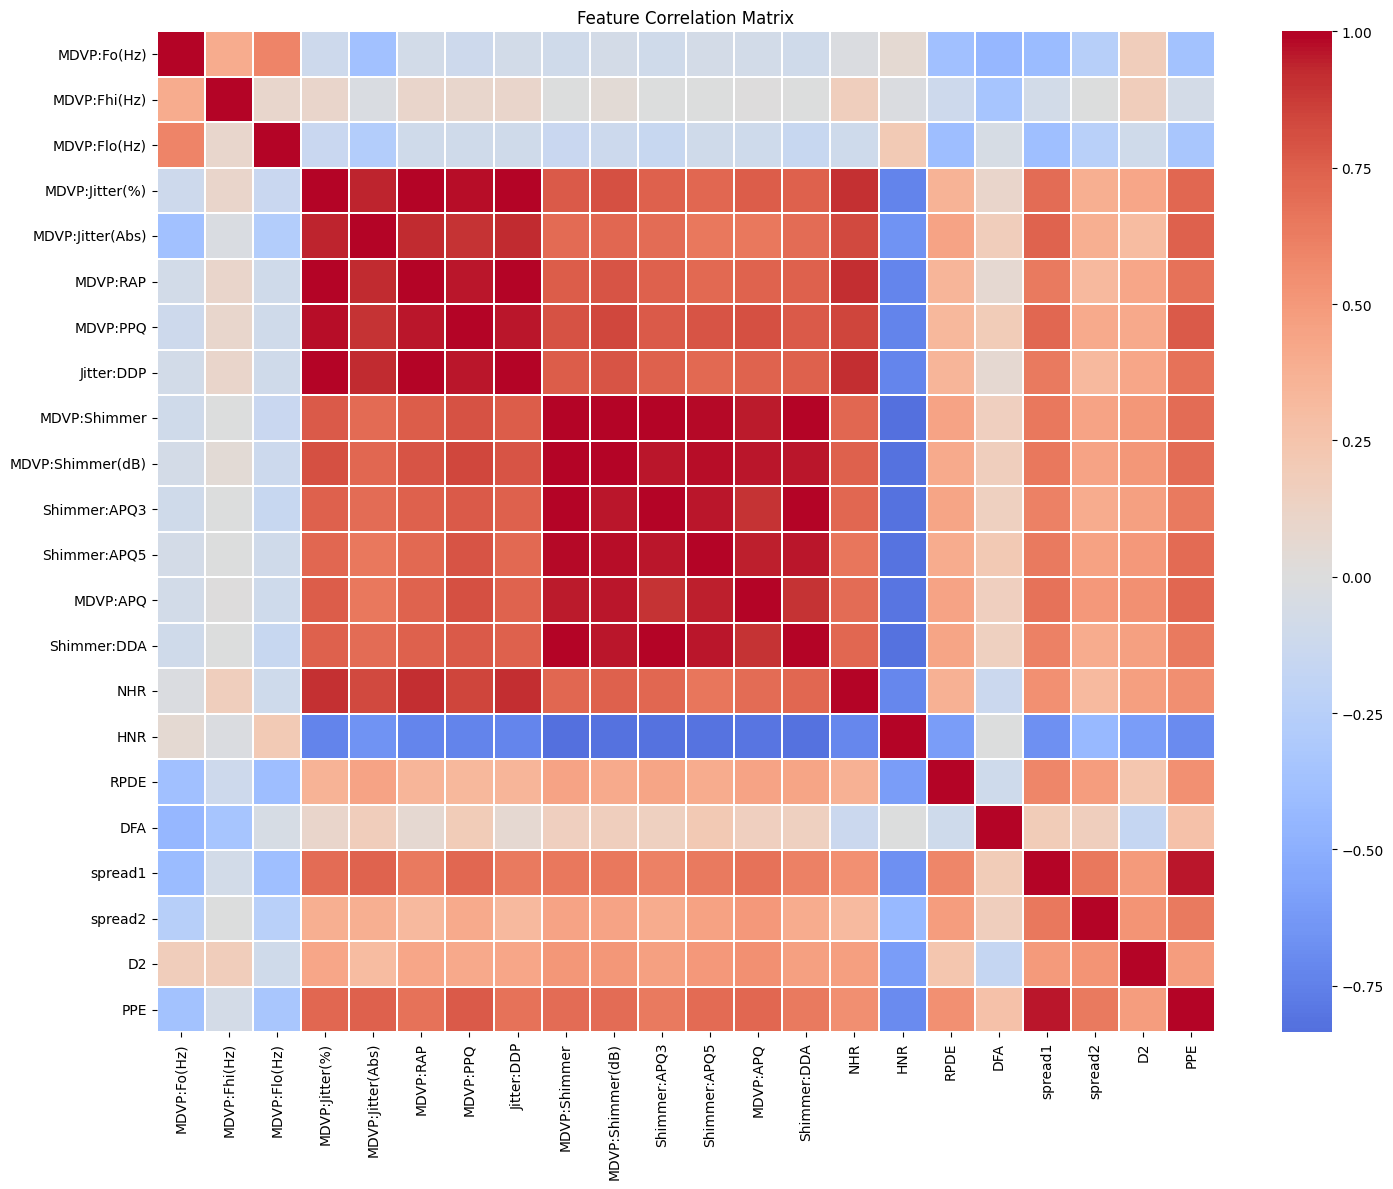

In [16]:
# ==========================================================
# CORRELATION ANALYSIS
# ==========================================================

correlation_matrix = X.corr()

plt.figure(
    figsize=(15, 12)
)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title(
    "Feature Correlation Matrix"
)

plt.tight_layout()

plt.show()

In [17]:
# ==========================================================
# TARGET CORRELATION
# ==========================================================

numeric_df = df_clean.select_dtypes(
    include=np.number
)

target_correlations = (
    numeric_df.corr()[target_column]
    .sort_values(
        ascending=False
    )
)

display(
    target_correlations.to_frame(
        "Correlation_With_Target"
    )
)

,Correlation_With_Target
status,1.000000
spread1,0.564838
PPE,0.531039
spread2,0.454842
MDVP:Shimmer,0.367430
MDVP:APQ,0.364316
Shimmer:APQ5,0.351148
MDVP:Shimmer(dB),0.350697
Shimmer:APQ3,0.347617
Shimmer:DDA,0.347608


In [18]:
# ==========================================================
# MANN-WHITNEY U TEST
# ==========================================================

classes = sorted(
    y.dropna().unique()
)

statistical_results = []

if len(classes) == 2:

    class_0 = classes[0]
    class_1 = classes[1]

    for feature in X.columns:

        group_0 = X.loc[
            y == class_0,
            feature
        ].dropna()

        group_1 = X.loc[
            y == class_1,
            feature
        ].dropna()

        try:

            statistic, p_value = mannwhitneyu(
                group_0,
                group_1,
                alternative="two-sided"
            )

        except Exception:

            statistic = np.nan
            p_value = np.nan

        statistical_results.append({

            "Feature":
                feature,

            "Mann_Whitney_U":
                statistic,

            "P_Value":
                p_value,

            "Significant_P<0.05":
                p_value < 0.05

        })


statistical_df = pd.DataFrame(
    statistical_results
)

statistical_df = statistical_df.sort_values(
    "P_Value"
)

display(
    statistical_df
)

,Feature,Mann_Whitney_U,P_Value,Significant_P<0.05
21,PPE,727.0,1.592799e-16,True
18,spread1,727.0,1.592799e-16,True
12,MDVP:APQ,1228.5,1.269268e-11,True
19,spread2,1315.0,7.159102e-11,True
4,MDVP:Jitter(Abs),1489.0,1.275739e-09,True
6,MDVP:PPQ,1501.5,2.401494e-09,True
9,MDVP:Shimmer(dB),1516.5,3.143455e-09,True
8,MDVP:Shimmer,1533.0,4.224740e-09,True
3,MDVP:Jitter(%),1568.5,7.897927e-09,True
7,Jitter:DDP,1570.5,8.180063e-09,True


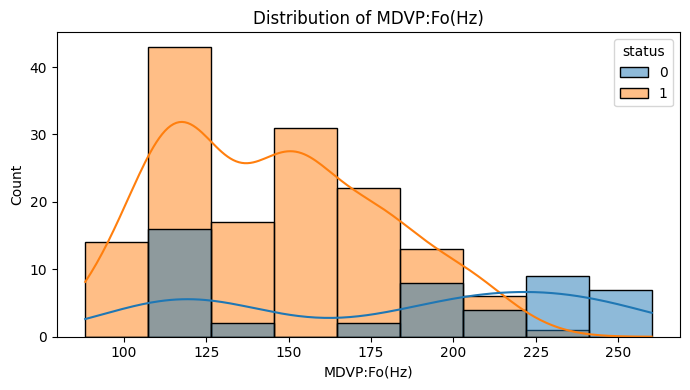

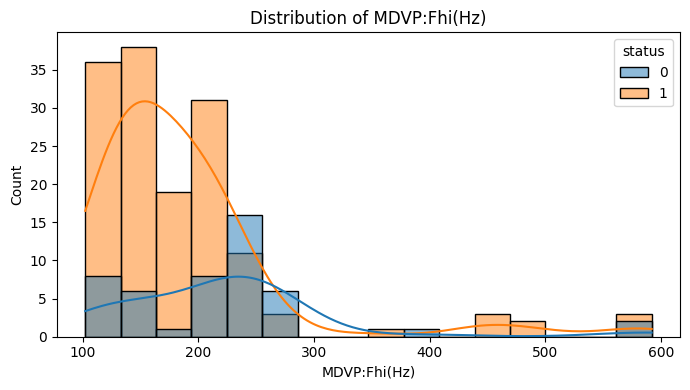

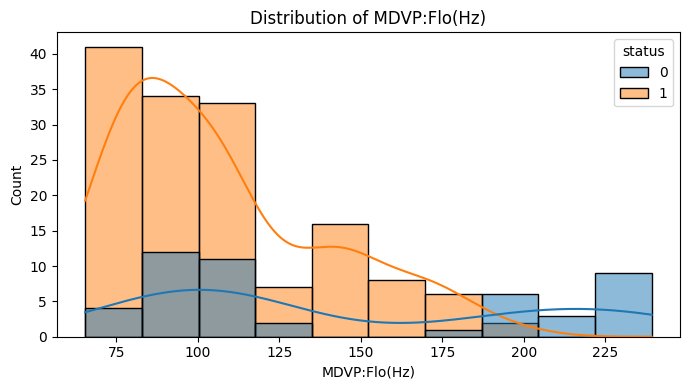

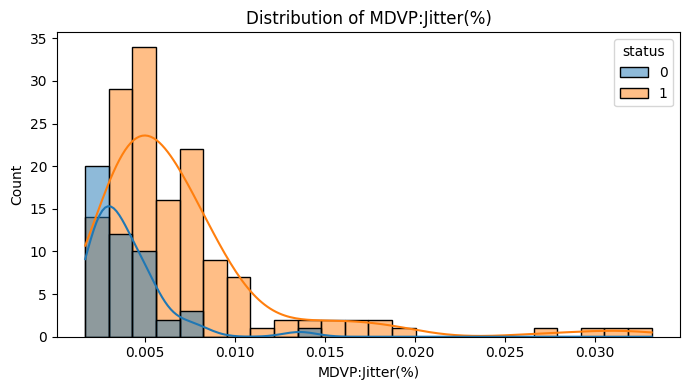

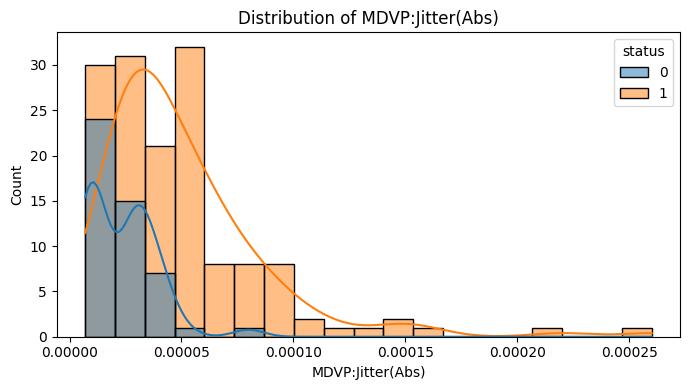

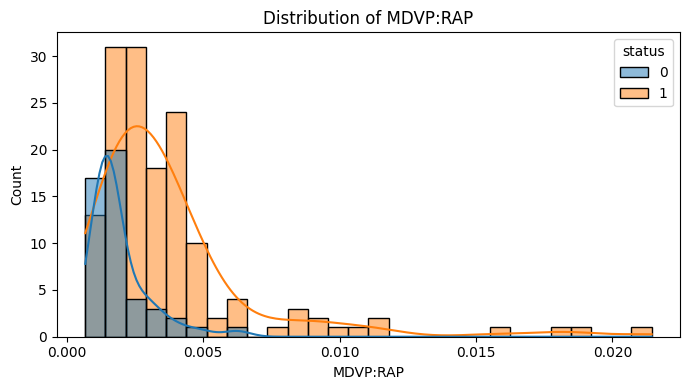

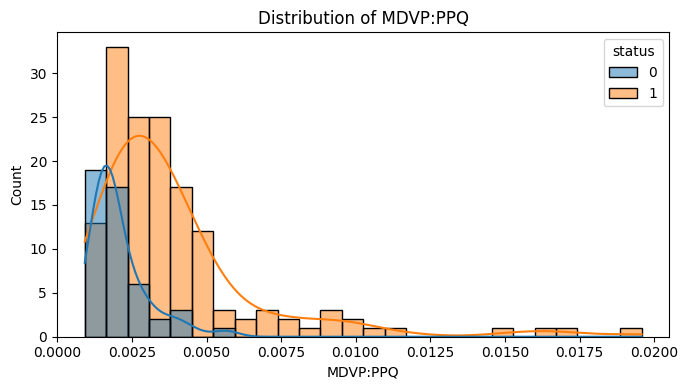

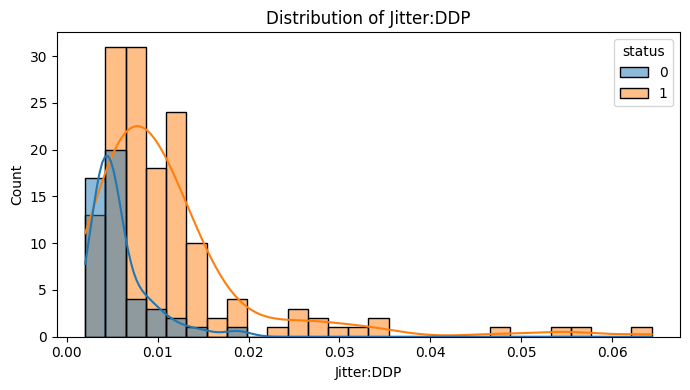

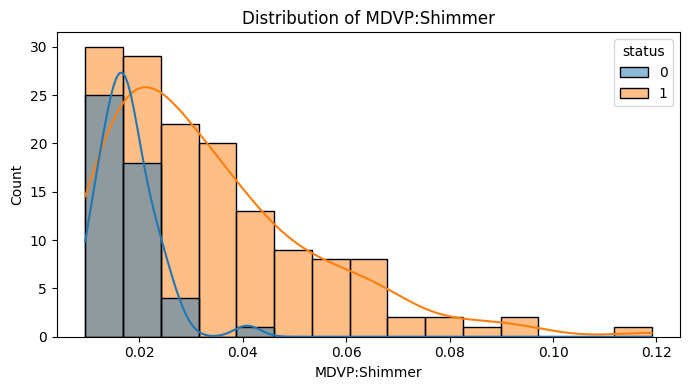

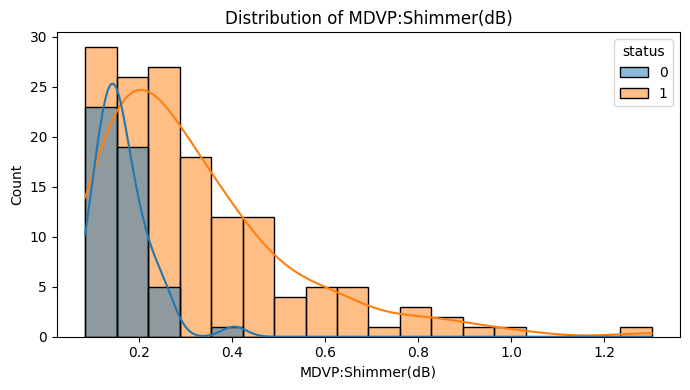

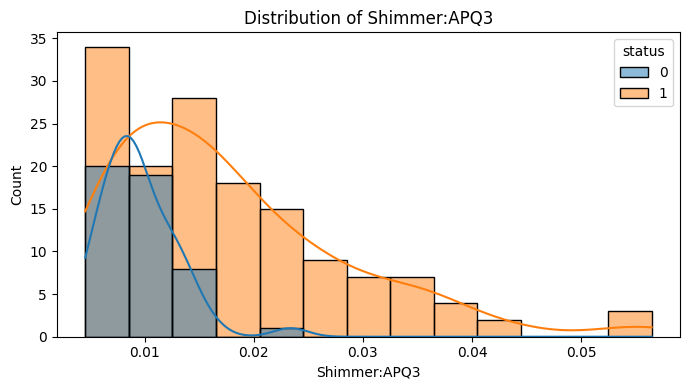

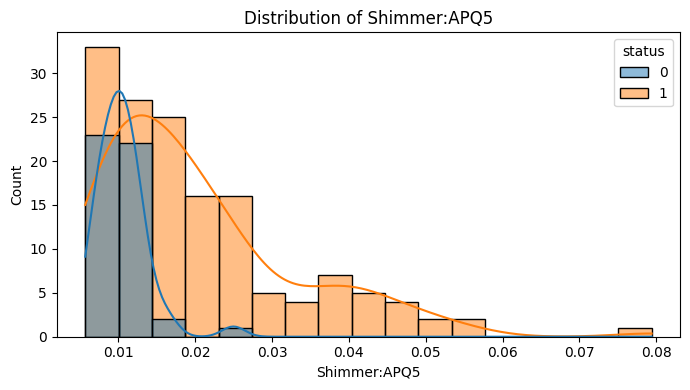

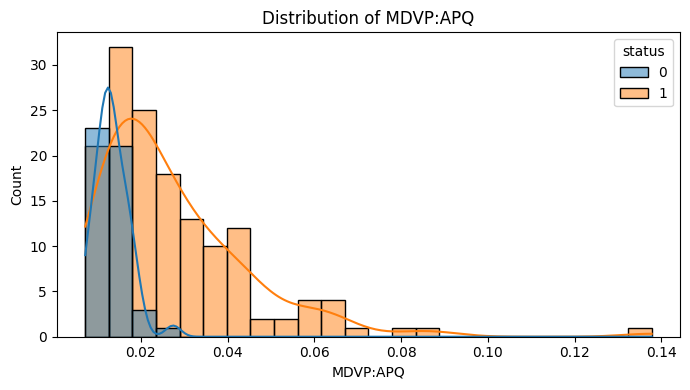

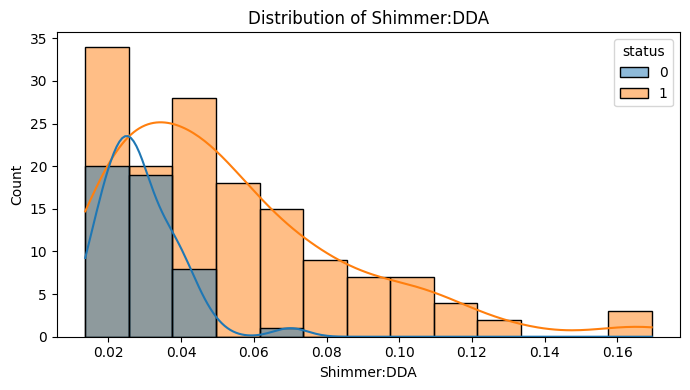

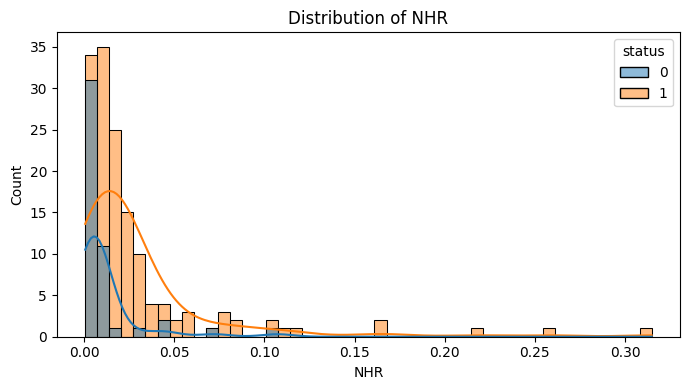

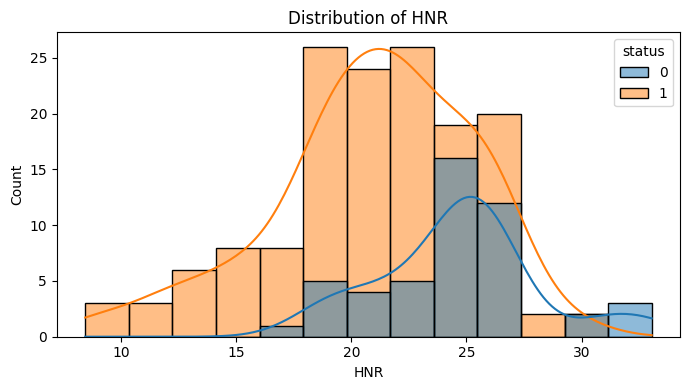

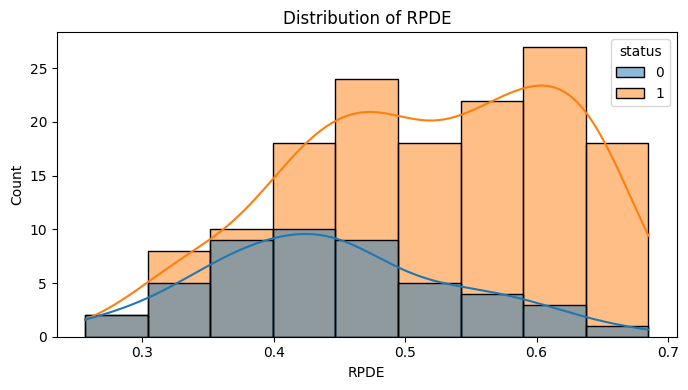

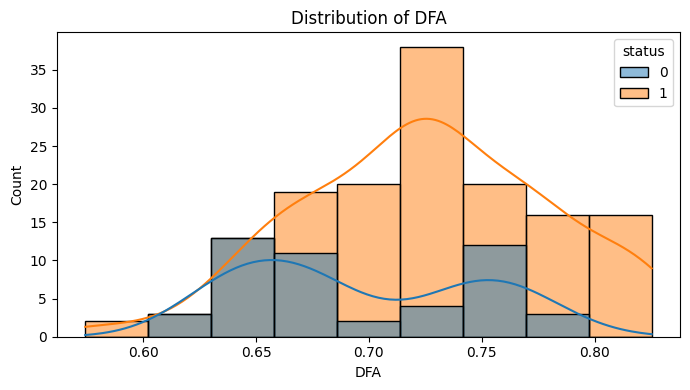

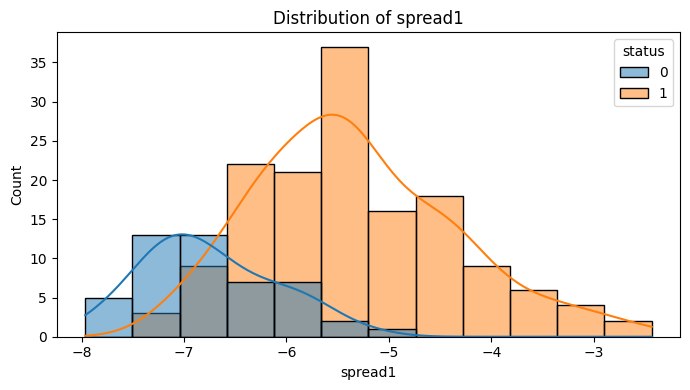

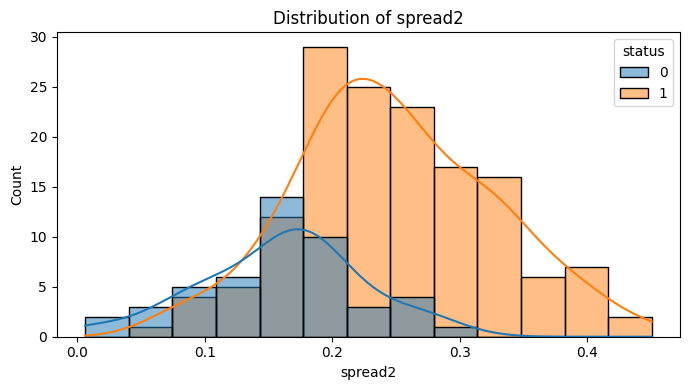

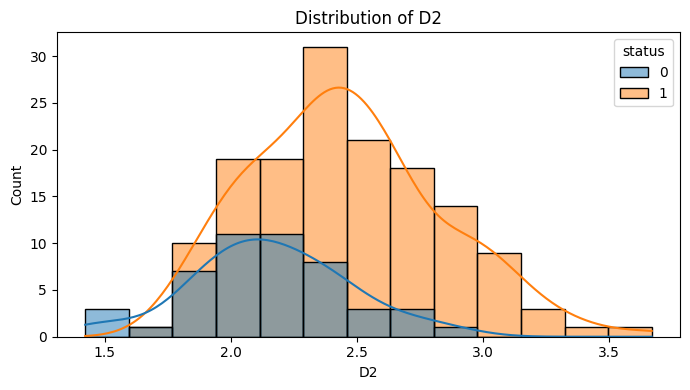

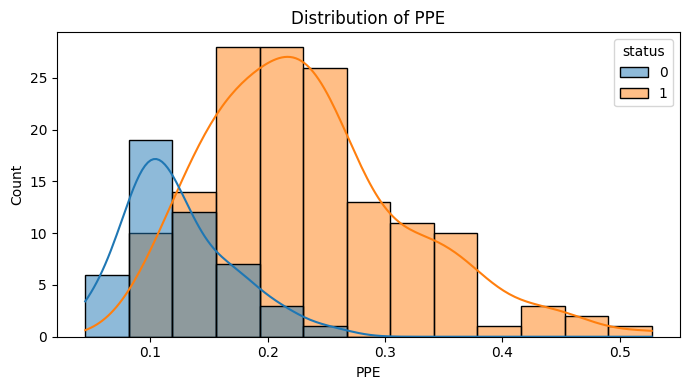

In [19]:
# ==========================================================
# FEATURE DISTRIBUTIONS
# ==========================================================

for feature in X.columns:

    plt.figure(
        figsize=(7, 4)
    )

    sns.histplot(
        data=df_clean,
        x=feature,
        hue=target_column,
        kde=True
    )

    plt.title(
        f"Distribution of {feature}"
    )

    plt.tight_layout()

    plt.show()

In [20]:
# ==========================================================
# SIGNIFICANT FEATURES ONLY
# ==========================================================

significant_features = statistical_df.loc[
    statistical_df["Significant_P<0.05"],
    "Feature"
].tolist()

print(
    "Significant features:",
    len(significant_features)
)

print(
    significant_features
)

Significant features: 22
['PPE', 'spread1', 'MDVP:APQ', 'spread2', 'MDVP:Jitter(Abs)', 'MDVP:PPQ', 'MDVP:Shimmer(dB)', 'MDVP:Shimmer', 'MDVP:Jitter(%)', 'Jitter:DDP', 'MDVP:RAP', 'NHR', 'Shimmer:APQ5', 'Shimmer:APQ3', 'Shimmer:DDA', 'HNR', 'D2', 'RPDE', 'MDVP:Fo(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Fhi(Hz)', 'DFA']


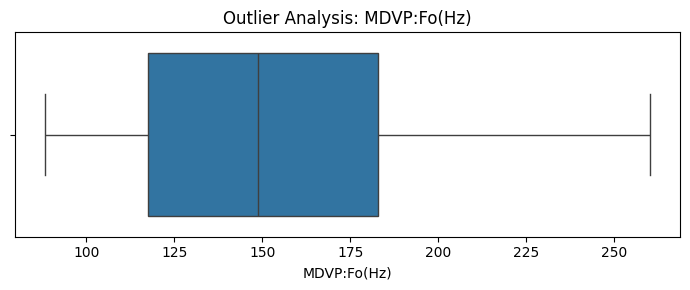

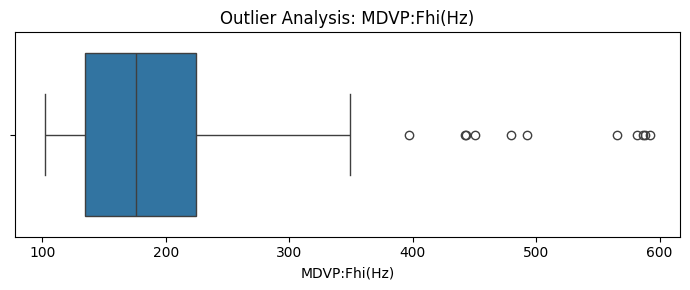

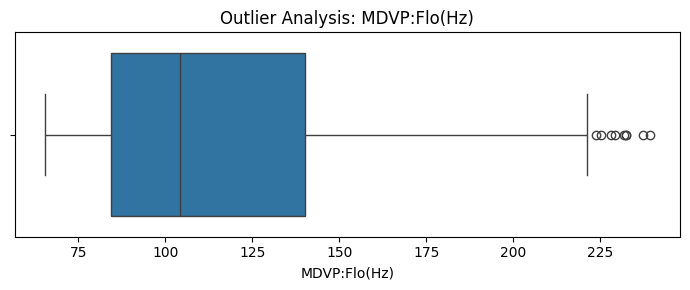

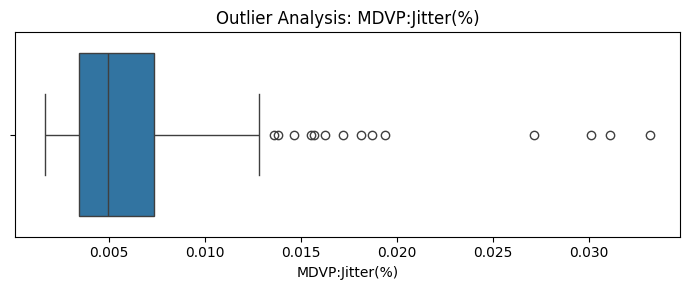

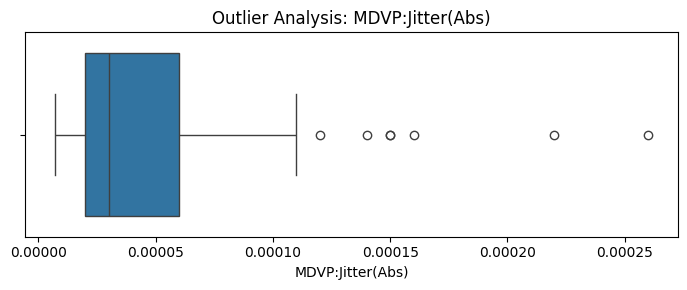

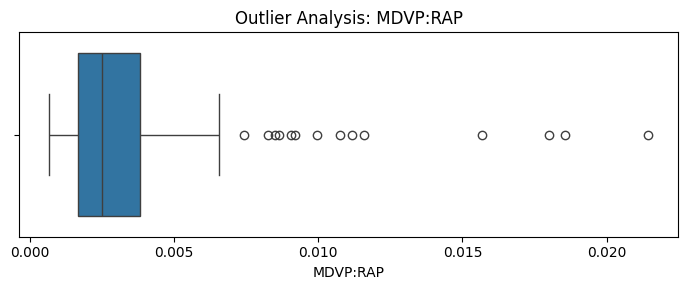

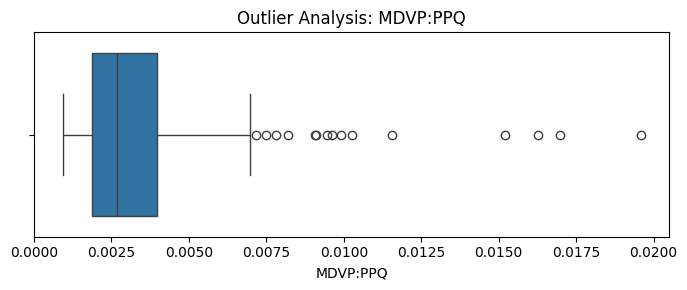

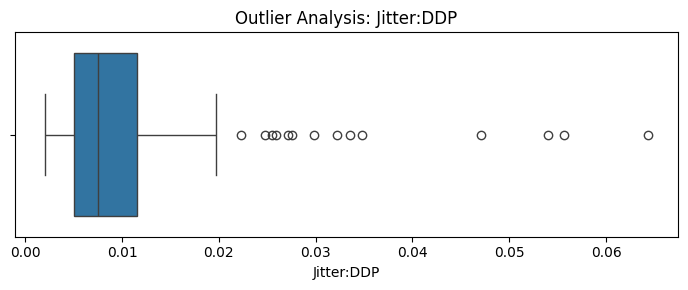

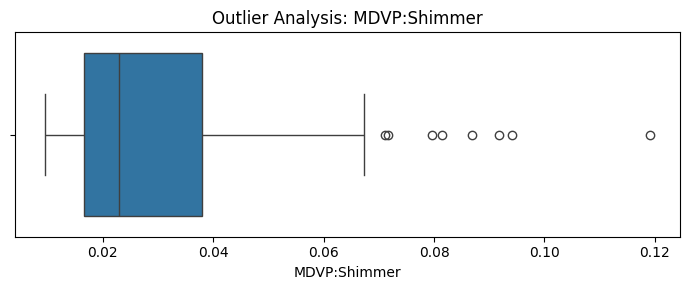

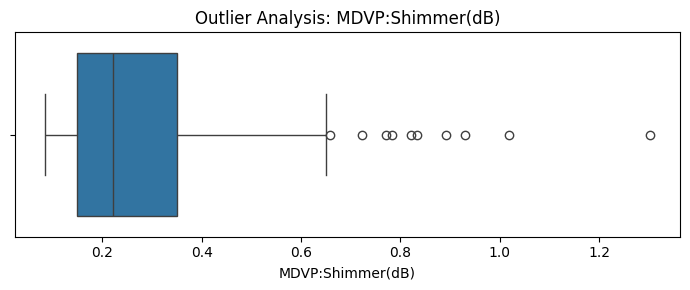

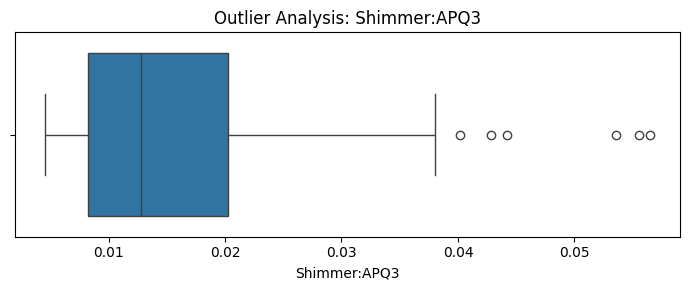

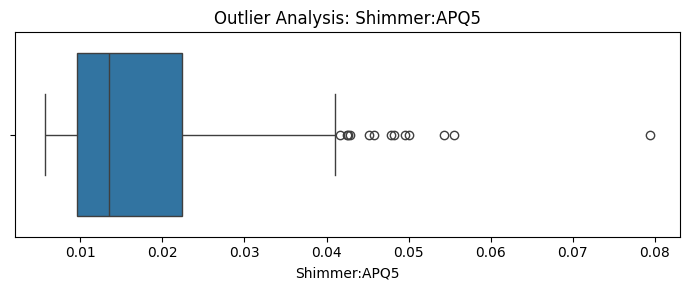

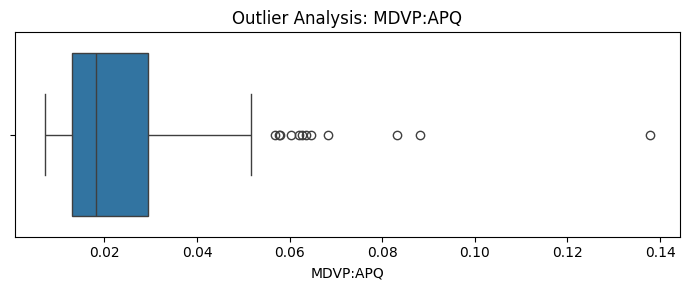

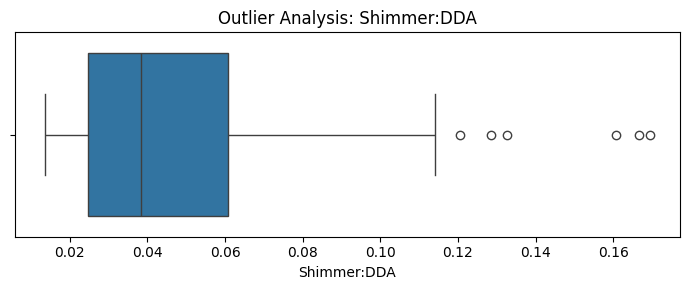

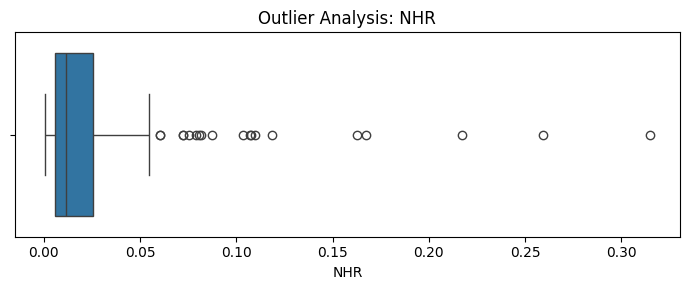

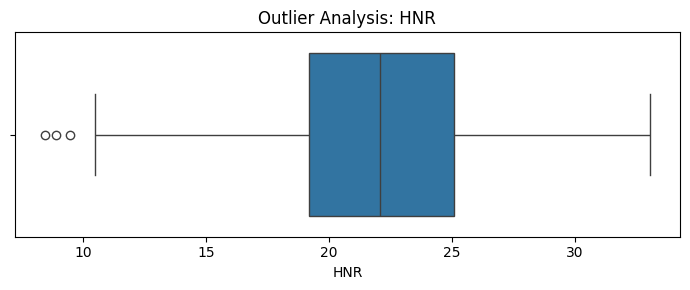

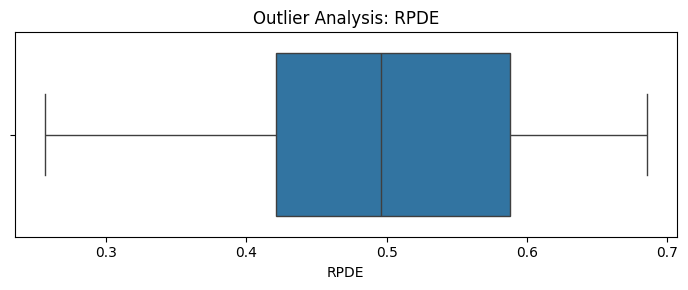

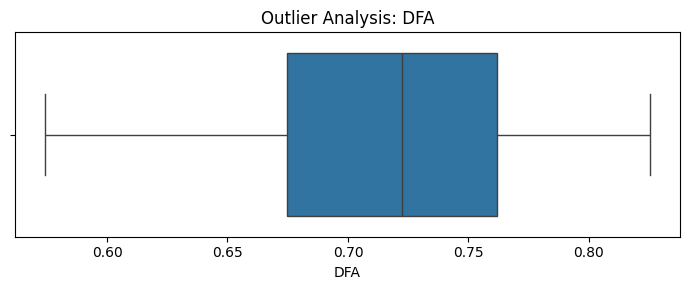

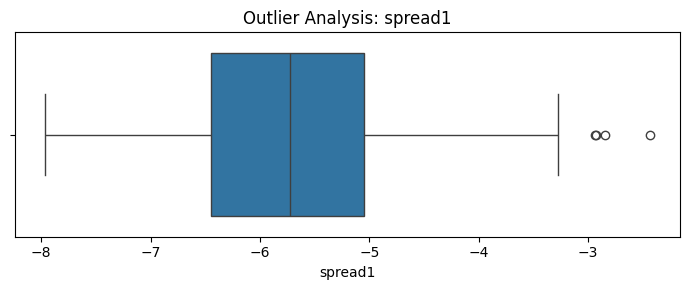

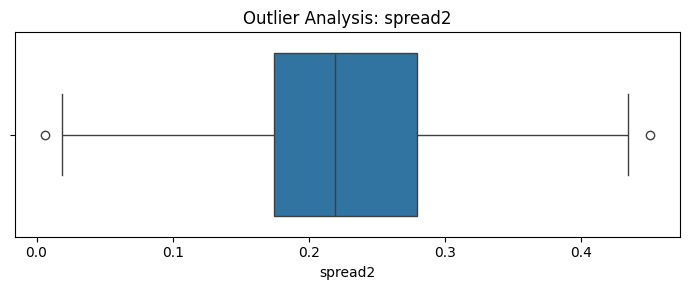

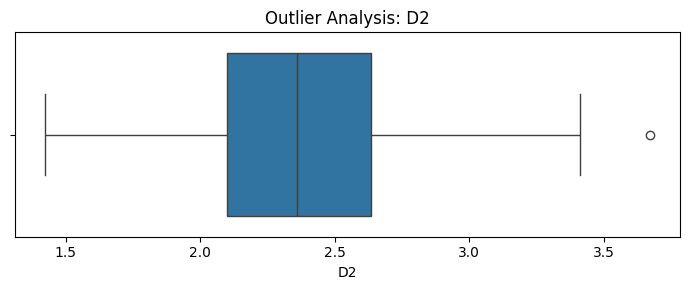

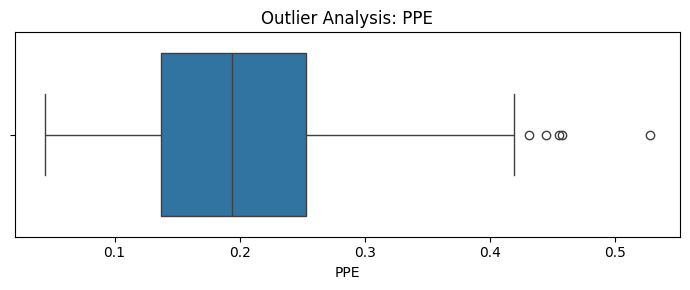

In [21]:
# ==========================================================
# OUTLIER ANALYSIS
# ==========================================================

for feature in X.columns:

    plt.figure(
        figsize=(7, 3)
    )

    sns.boxplot(
        x=X[feature]
    )

    plt.title(
        f"Outlier Analysis: {feature}"
    )

    plt.tight_layout()

    plt.show()

In [22]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

Training samples: 156
Testing samples: 39


In [23]:
# ==========================================================
# MACHINE LEARNING MODELS
# ==========================================================

models = {

    "Logistic Regression":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced"
                )
            )

        ]),


    "SVM":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",
                SVC(
                    probability=True,
                    class_weight="balanced",
                    random_state=42
                )
            )

        ]),


    "KNN":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "scaler",
                StandardScaler()
            ),

            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=5
                )
            )

        ]),


    "Decision Tree":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "model",
                DecisionTreeClassifier(
                    max_depth=5,
                    class_weight="balanced",
                    random_state=42
                )
            )

        ]),


    "Random Forest":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    class_weight="balanced",
                    random_state=42
                )
            )

        ]),


    "Extra Trees":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "model",
                ExtraTreesClassifier(
                    n_estimators=500,
                    class_weight="balanced",
                    random_state=42
                )
            )

        ]),


    "Gradient Boosting":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "model",
                GradientBoostingClassifier(
                    n_estimators=200,
                    random_state=42
                )
            )

        ]),


    "AdaBoost":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "model",
                AdaBoostClassifier(
                    n_estimators=200,
                    random_state=42
                )
            )

        ]),


    "Naive Bayes":

        Pipeline([

            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),

            (
                "model",
                GaussianNB()
            )

        ])

}

print(
    "Models:",
    len(models)
)

print(
    list(models.keys())
)

Models: 9
['Logistic Regression', 'SVM', 'KNN', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost', 'Naive Bayes']


In [24]:
# ==========================================================
# MODEL TRAINING AND EVALUATION
# ==========================================================

results = []

trained_models = {}

for name, model in models.items():

    print(
        f"Training {name}..."
    )

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    prediction = model.predict(
        X_test
    )

    probability = None

    if hasattr(
        model,
        "predict_proba"
    ):

        probability = model.predict_proba(
            X_test
        )[:, 1]


    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    sensitivity = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_test,
        prediction
    )


    if probability is not None:

        roc_auc = roc_auc_score(
            y_test,
            probability
        )

        pr_auc = average_precision_score(
            y_test,
            probability
        )

    else:

        roc_auc = np.nan
        pr_auc = np.nan


    cm = confusion_matrix(
        y_test,
        prediction
    )


    if cm.shape == (2, 2):

        tn, fp, fn, tp = cm.ravel()

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else 0
        )

    else:

        specificity = np.nan


    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Sensitivity": sensitivity,

        "Specificity": specificity,

        "F1_Score": f1,

        "ROC_AUC": roc_auc,

        "PR_AUC": pr_auc,

        "MCC": mcc

    })


results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "ROC_AUC",
    ascending=False
)

display(
    results_df
)

Training Logistic Regression...
Training SVM...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training AdaBoost...
Training Naive Bayes...


,Model,Accuracy,Precision,Sensitivity,Specificity,F1_Score,ROC_AUC,PR_AUC,MCC
5,Extra Trees,0.923077,0.933333,0.965517,0.8,0.949153,0.986207,0.995820,0.793363
6,Gradient Boosting,0.923077,0.964286,0.931034,0.9,0.947368,0.979310,0.993400,0.806385
7,AdaBoost,0.897436,0.931034,0.931034,0.8,0.931034,0.975862,0.991821,0.731034
4,Random Forest,0.923077,0.933333,0.965517,0.8,0.949153,0.972414,0.990683,0.793363
2,KNN,0.923077,0.933333,0.965517,0.8,0.949153,0.963793,0.980966,0.793363
1,SVM,0.794872,1.000000,0.724138,1.0,0.840000,0.944828,0.980919,0.634270
0,Logistic Regression,0.769231,0.954545,0.724138,0.9,0.823529,0.927586,0.975316,0.549596
8,Naive Bayes,0.666667,1.000000,0.551724,1.0,0.711111,0.868966,0.952875,0.489776
3,Decision Tree,0.769231,0.857143,0.827586,0.6,0.842105,0.744828,0.850742,0.414904


In [25]:
# ==========================================================
# 10-FOLD STRATIFIED CROSS VALIDATION
# ==========================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    print(
        f"Cross-validating {name}..."
    )

    scores = cross_validate(

        model,

        X,

        y,

        cv=cv,

        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],

        n_jobs=-1

    )


    cv_results.append({

        "Model":
            name,

        "Accuracy_Mean":
            scores[
                "test_accuracy"
            ].mean(),

        "Accuracy_STD":
            scores[
                "test_accuracy"
            ].std(),

        "Precision_Mean":
            scores[
                "test_precision"
            ].mean(),

        "Recall_Mean":
            scores[
                "test_recall"
            ].mean(),

        "F1_Mean":
            scores[
                "test_f1"
            ].mean(),

        "ROC_AUC_Mean":
            scores[
                "test_roc_auc"
            ].mean(),

        "ROC_AUC_STD":
            scores[
                "test_roc_auc"
            ].std()

    })


cv_df = pd.DataFrame(
    cv_results
)

cv_df = cv_df.sort_values(
    "ROC_AUC_Mean",
    ascending=False
)

display(
    cv_df
)

Cross-validating Logistic Regression...
Cross-validating SVM...
Cross-validating KNN...
Cross-validating Decision Tree...
Cross-validating Random Forest...
Cross-validating Extra Trees...
Cross-validating Gradient Boosting...
Cross-validating AdaBoost...
Cross-validating Naive Bayes...


,Model,Accuracy_Mean,Accuracy_STD,Precision_Mean,Recall_Mean,F1_Mean,ROC_AUC_Mean,ROC_AUC_STD
7,AdaBoost,0.927632,0.047707,0.936471,0.972857,0.953477,0.976571,0.025429
5,Extra Trees,0.927632,0.042142,0.929167,0.979524,0.953304,0.974381,0.029522
2,KNN,0.918421,0.050606,0.945595,0.946190,0.945026,0.972524,0.019251
4,Random Forest,0.911579,0.062698,0.917969,0.972381,0.943335,0.966952,0.034148
6,Gradient Boosting,0.917105,0.053960,0.939405,0.951905,0.945223,0.963429,0.039411
1,SVM,0.830789,0.068835,0.976282,0.796190,0.874869,0.941190,0.040545
0,Logistic Regression,0.783947,0.081174,0.902399,0.802381,0.848205,0.910190,0.058127
8,Naive Bayes,0.713158,0.101355,0.972863,0.640000,0.761411,0.863476,0.083859
3,Decision Tree,0.886842,0.064974,0.932532,0.919524,0.924302,0.851429,0.088077


Best model based on test ROC-AUC: Extra Trees


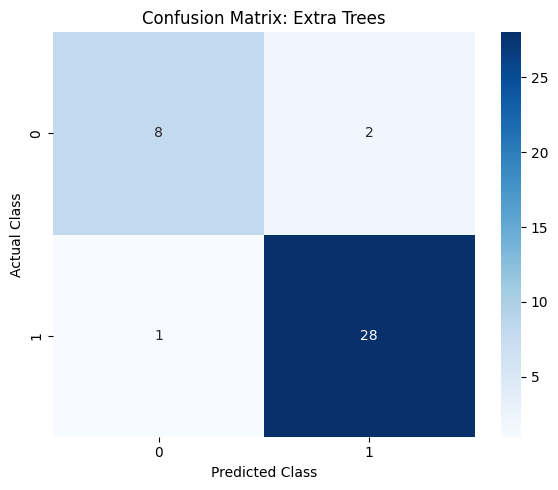

In [26]:
# ==========================================================
# BEST MODEL
# ==========================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print(
    "Best model based on test ROC-AUC:",
    best_model_name
)

best_prediction = best_model.predict(
    X_test
)

best_probability = best_model.predict_proba(
    X_test
)[:, 1]


cm = confusion_matrix(
    y_test,
    best_prediction
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.title(
    f"Confusion Matrix: {best_model_name}"
)

plt.tight_layout()

plt.show()

In [27]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(
    classification_report(
        y_test,
        best_prediction,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.8889    0.8000    0.8421        10
           1     0.9333    0.9655    0.9492        29

    accuracy                         0.9231        39
   macro avg     0.9111    0.8828    0.8956        39
weighted avg     0.9219    0.9231    0.9217        39



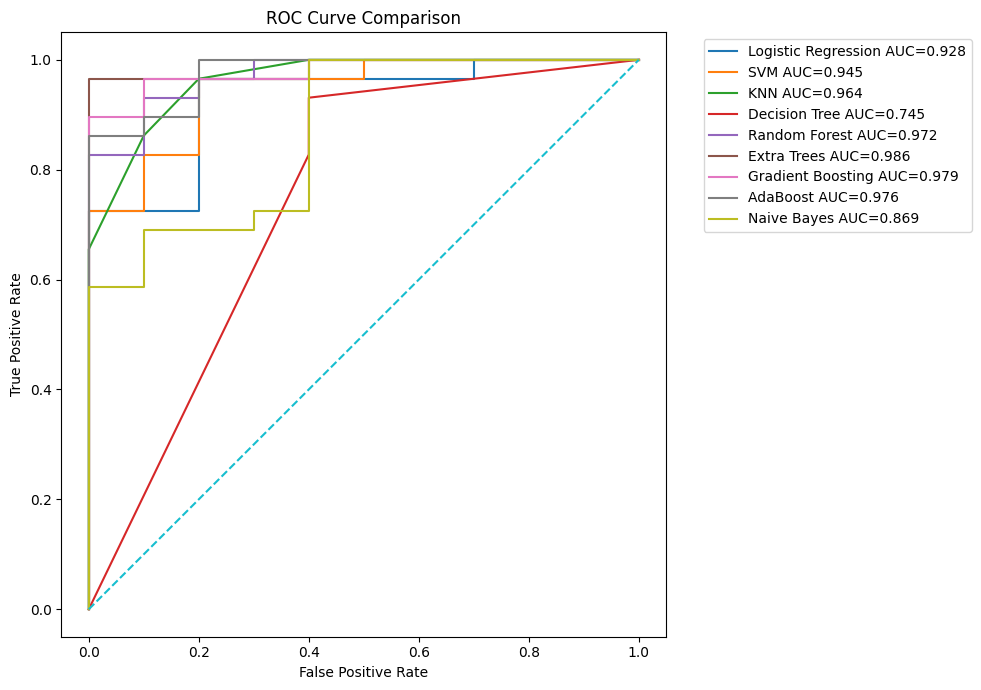

In [28]:
# ==========================================================
# ROC CURVE
# ==========================================================

plt.figure(
    figsize=(10, 7)
)

for name, model in trained_models.items():

    probability = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC={auc:.3f}"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

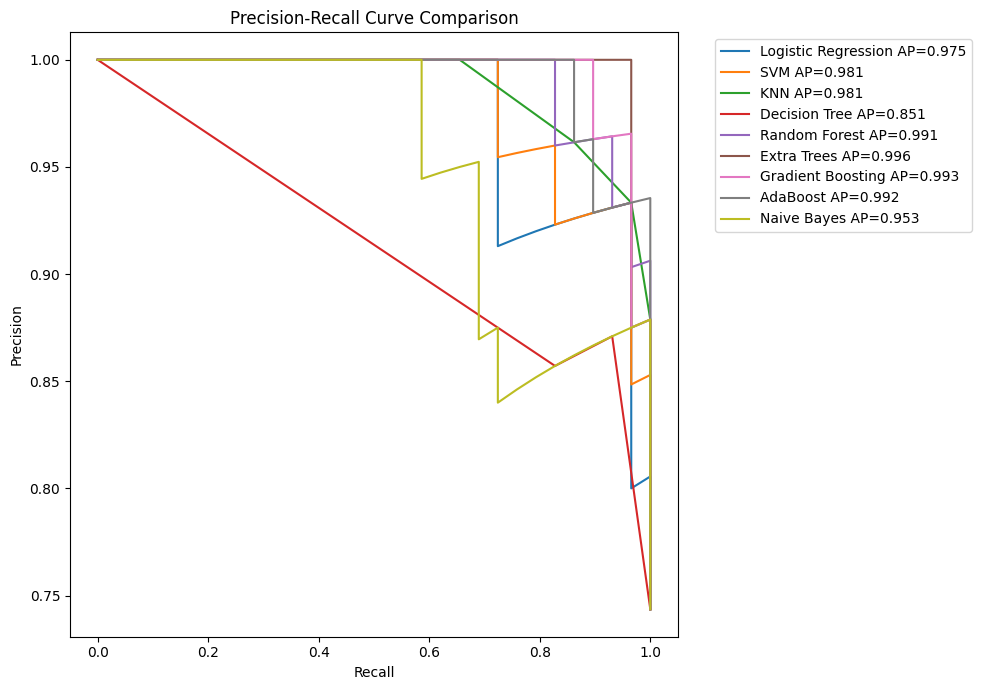

In [29]:
# ==========================================================
# PRECISION RECALL CURVES
# ==========================================================

plt.figure(
    figsize=(10, 7)
)

for name, model in trained_models.items():

    probability = model.predict_proba(
        X_test
    )[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        probability
    )

    ap = average_precision_score(
        y_test,
        probability
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} AP={ap:.3f}"
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

,Feature,Importance
21,PPE,0.122418
18,spread1,0.120323
11,Shimmer:APQ5,0.069266
12,MDVP:APQ,0.062327
19,spread2,0.051845
8,MDVP:Shimmer,0.050659
5,MDVP:RAP,0.047664
7,Jitter:DDP,0.042574
20,D2,0.042564
0,MDVP:Fo(Hz),0.042002


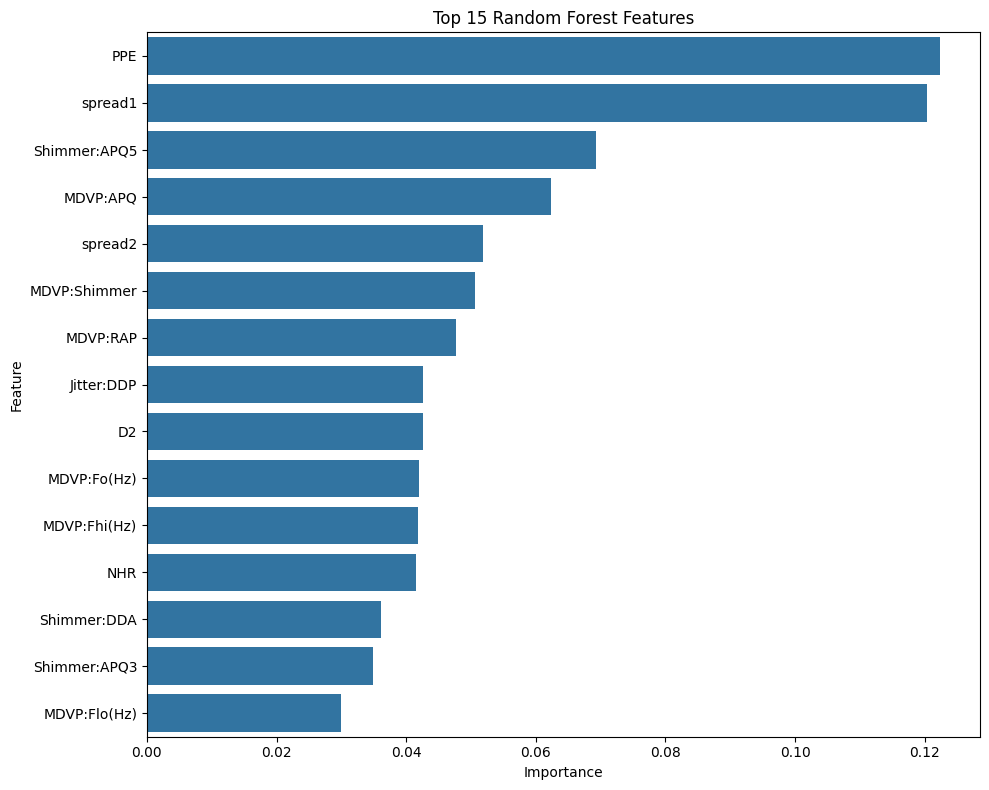

In [30]:
# ==========================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================================

rf = trained_models[
    "Random Forest"
]

rf_model = rf.named_steps[
    "model"
]

importance_df = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance":
        rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(
    importance_df
)


plt.figure(
    figsize=(10, 8)
)

top_features = importance_df.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Features"
)

plt.tight_layout()

plt.show()

In [31]:
# ==========================================================
# PERMUTATION IMPORTANCE
# ==========================================================

permutation = permutation_importance(

    rf,

    X_test,

    y_test,

    n_repeats=20,

    random_state=42,

    scoring="roc_auc"

)


permutation_df = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance_Mean":
        permutation.importances_mean,

    "Importance_STD":
        permutation.importances_std

})


permutation_df = permutation_df.sort_values(
    "Importance_Mean",
    ascending=False
)

display(
    permutation_df
)

,Feature,Importance_Mean,Importance_STD
1,MDVP:Fhi(Hz),0.021638,0.006009
0,MDVP:Fo(Hz),0.020690,0.008105
21,PPE,0.013707,0.011610
19,spread2,0.012759,0.014925
17,DFA,0.011466,0.006102
11,Shimmer:APQ5,0.005862,0.008815
18,spread1,0.004483,0.009243
16,RPDE,0.003621,0.003773
9,MDVP:Shimmer(dB),0.003276,0.003529
20,D2,0.002414,0.009243


In [32]:
# ==========================================================
# MUTUAL INFORMATION
# ==========================================================

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = imputer.fit_transform(
    X
)

mi_scores = mutual_info_classif(
    X_imputed,
    y,
    random_state=42
)

mi_df = pd.DataFrame({

    "Feature":
        X.columns,

    "Mutual_Information":
        mi_scores

})

mi_df = mi_df.sort_values(
    "Mutual_Information",
    ascending=False
)

display(
    mi_df
)

,Feature,Mutual_Information
21,PPE,0.253982
18,spread1,0.221368
0,MDVP:Fo(Hz),0.206593
19,spread2,0.192002
4,MDVP:Jitter(Abs),0.182199
12,MDVP:APQ,0.181021
2,MDVP:Flo(Hz),0.174088
1,MDVP:Fhi(Hz),0.140713
15,HNR,0.132462
14,NHR,0.115354


In [33]:
# ==========================================================
# ANOVA FEATURE SELECTION
# ==========================================================

f_values, p_values = f_classif(
    X_imputed,
    y
)

anova_df = pd.DataFrame({

    "Feature":
        X.columns,

    "F_Value":
        f_values,

    "P_Value":
        p_values

})

anova_df = anova_df.sort_values(
    "F_Value",
    ascending=False
)

display(
    anova_df
)

,Feature,F_Value,P_Value
18,spread1,90.424219,7.909651e-18
21,PPE,75.803195,1.392619e-15
19,spread2,50.343165,2.391729e-11
0,MDVP:Fo(Hz),33.286577,3.121919e-08
2,MDVP:Flo(Hz),32.612875,4.197004e-08
8,MDVP:Shimmer,30.122600,1.264702e-07
12,MDVP:APQ,29.536350,1.643238e-07
15,HNR,29.015927,2.074677e-07
11,Shimmer:APQ5,27.145033,4.823575e-07
9,MDVP:Shimmer(dB),27.065484,5.000743e-07


In [34]:
# ==========================================================
# PRINCIPAL COMPONENT ANALYSIS
# ==========================================================

pca_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "pca",
        PCA()
    )

])

X_pca = pca_pipeline.fit_transform(
    X
)

pca_model = pca_pipeline.named_steps[
    "pca"
]

explained_variance = (
    pca_model
    .explained_variance_ratio_
)

cumulative_variance = np.cumsum(
    explained_variance
)

pca_results = pd.DataFrame({

    "Principal_Component":
        range(
            1,
            len(explained_variance) + 1
        ),

    "Explained_Variance":
        explained_variance,

    "Cumulative_Variance":
        cumulative_variance

})

display(
    pca_results
)

,Principal_Component,Explained_Variance,Cumulative_Variance
0,1,5.890050e-01,0.589005
1,2,1.129943e-01,0.701999
2,3,7.009226e-02,0.772092
3,4,6.659028e-02,0.838682
4,5,4.426891e-02,0.882951
5,6,3.314129e-02,0.916092
6,7,2.510204e-02,0.941194
7,8,1.647288e-02,0.957667
8,9,1.317446e-02,0.970841
9,10,1.018756e-02,0.981029


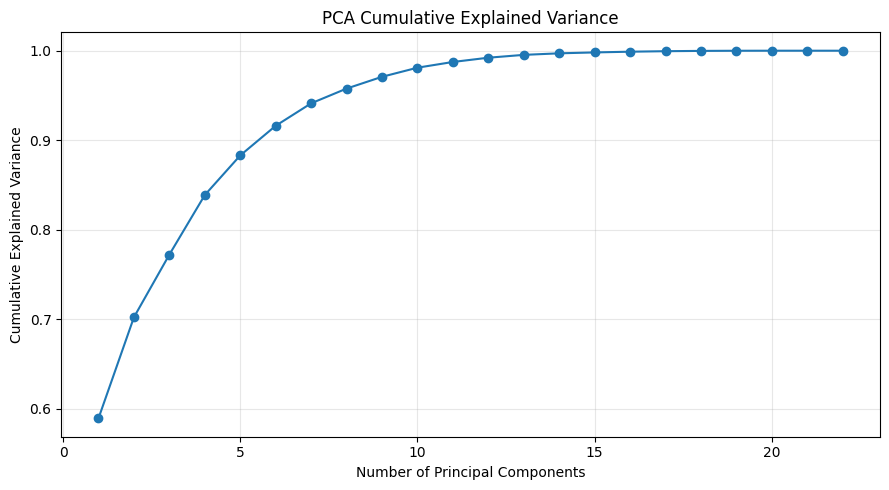

In [35]:
# ==========================================================
# PCA EXPLAINED VARIANCE
# ==========================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Cumulative Explained Variance"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

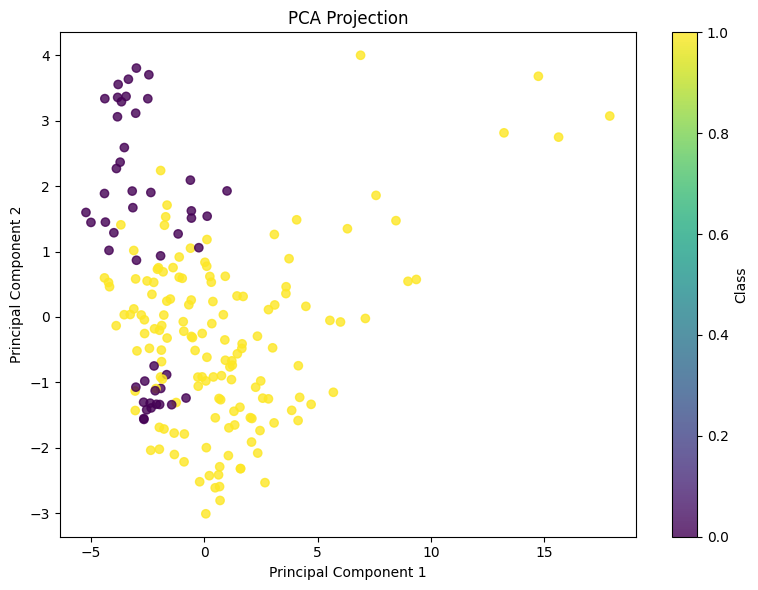

In [36]:
# ==========================================================
# PCA 2D VISUALIZATION
# ==========================================================

pca_2d = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "pca",
        PCA(
            n_components=2
        )
    )

])

X_pca_2d = pca_2d.fit_transform(
    X
)


plt.figure(
    figsize=(8, 6)
)

scatter = plt.scatter(

    X_pca_2d[:, 0],

    X_pca_2d[:, 1],

    c=y,

    alpha=0.8

)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA Projection"
)

plt.colorbar(
    scatter,
    label="Class"
)

plt.tight_layout()

plt.show()

In [37]:
# ==========================================================
# SVM HYPERPARAMETER OPTIMIZATION
# ==========================================================

svm_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        )
    )

])


parameter_grid = {

    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "model__gamma": [
        "scale",
        0.001,
        0.01,
        0.1,
        1
    ],

    "model__kernel": [
        "rbf",
        "linear"
    ]

}


grid_search = GridSearchCV(

    svm_pipeline,

    parameter_grid,

    cv=5,

    scoring="roc_auc",

    n_jobs=-1,

    refit=True

)


grid_search.fit(
    X_train,
    y_train
)


print(
    "Best parameters:"
)

print(
    grid_search.best_params_
)

print(
    "\nBest CV ROC-AUC:"
)

print(
    grid_search.best_score_
)

Best parameters:
{'model__C': 10, 'model__gamma': 0.1, 'model__kernel': 'rbf'}

Best CV ROC-AUC:
0.9781508799171842


In [38]:
# ==========================================================
# OPTIMIZED SVM EVALUATION
# ==========================================================

optimized_model = grid_search.best_estimator_

optimized_prediction = (
    optimized_model.predict(
        X_test
    )
)

optimized_probability = (
    optimized_model.predict_proba(
        X_test
    )[:, 1]
)


optimized_accuracy = accuracy_score(
    y_test,
    optimized_prediction
)

optimized_precision = precision_score(
    y_test,
    optimized_prediction,
    zero_division=0
)

optimized_recall = recall_score(
    y_test,
    optimized_prediction,
    zero_division=0
)

optimized_f1 = f1_score(
    y_test,
    optimized_prediction,
    zero_division=0
)

optimized_auc = roc_auc_score(
    y_test,
    optimized_probability
)

optimized_mcc = matthews_corrcoef(
    y_test,
    optimized_prediction
)


optimized_results = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Sensitivity",

        "F1 Score",

        "ROC-AUC",

        "MCC"

    ],

    "Value": [

        optimized_accuracy,

        optimized_precision,

        optimized_recall,

        optimized_f1,

        optimized_auc,

        optimized_mcc

    ]

})


display(
    optimized_results
)

,Metric,Value
0,Accuracy,0.923077
1,Precision,0.964286
2,Sensitivity,0.931034
3,F1 Score,0.947368
4,ROC-AUC,0.982759
5,MCC,0.806385


In [39]:
# ==========================================================
# SOFT VOTING ENSEMBLE
# ==========================================================

ensemble = VotingClassifier(

    estimators=[

        (
            "LogisticRegression",

            LogisticRegression(
                max_iter=5000,
                class_weight="balanced"
            )
        ),

        (
            "SVM",

            SVC(
                probability=True,
                class_weight="balanced",
                random_state=42
            )
        ),

        (
            "RandomForest",

            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42
            )
        )

    ],

    voting="soft"

)


ensemble_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        ensemble
    )

])


ensemble_pipeline.fit(
    X_train,
    y_train
)


ensemble_prediction = (
    ensemble_pipeline.predict(
        X_test
    )
)

ensemble_probability = (
    ensemble_pipeline.predict_proba(
        X_test
    )[:, 1]
)


ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_prediction
)

ensemble_precision = precision_score(
    y_test,
    ensemble_prediction,
    zero_division=0
)

ensemble_recall = recall_score(
    y_test,
    ensemble_prediction,
    zero_division=0
)

ensemble_f1 = f1_score(
    y_test,
    ensemble_prediction,
    zero_division=0
)

ensemble_auc = roc_auc_score(
    y_test,
    ensemble_probability
)

ensemble_mcc = matthews_corrcoef(
    y_test,
    ensemble_prediction
)


ensemble_results = pd.DataFrame({

    "Metric": [

        "Accuracy",
        "Precision",
        "Sensitivity",
        "F1 Score",
        "ROC-AUC",
        "MCC"

    ],

    "Value": [

        ensemble_accuracy,
        ensemble_precision,
        ensemble_recall,
        ensemble_f1,
        ensemble_auc,
        ensemble_mcc

    ]

})


display(
    ensemble_results
)

,Metric,Value
0,Accuracy,0.897436
1,Precision,0.931034
2,Sensitivity,0.931034
3,F1 Score,0.931034
4,ROC-AUC,0.951724
5,MCC,0.731034


In [40]:
# ==========================================================
# FINAL MODEL COMPARISON
# ==========================================================

final_results = results_df.copy()

ensemble_row = pd.DataFrame({

    "Model": [
        "Voting Ensemble"
    ],

    "Accuracy": [
        ensemble_accuracy
    ],

    "Precision": [
        ensemble_precision
    ],

    "Sensitivity": [
        ensemble_recall
    ],

    "Specificity": [
        np.nan
    ],

    "F1_Score": [
        ensemble_f1
    ],

    "ROC_AUC": [
        ensemble_auc
    ],

    "PR_AUC": [
        average_precision_score(
            y_test,
            ensemble_probability
        )
    ],

    "MCC": [
        ensemble_mcc
    ]

})


final_results = pd.concat(
    [
        final_results,
        ensemble_row
    ],
    ignore_index=True
)


final_results = final_results.sort_values(
    "ROC_AUC",
    ascending=False
)


final_results["Rank"] = range(
    1,
    len(final_results) + 1
)


display(
    final_results
)

,Model,Accuracy,Precision,Sensitivity,Specificity,F1_Score,ROC_AUC,PR_AUC,MCC,Rank
0,Extra Trees,0.923077,0.933333,0.965517,0.8,0.949153,0.986207,0.995820,0.793363,1
1,Gradient Boosting,0.923077,0.964286,0.931034,0.9,0.947368,0.979310,0.993400,0.806385,2
2,AdaBoost,0.897436,0.931034,0.931034,0.8,0.931034,0.975862,0.991821,0.731034,3
3,Random Forest,0.923077,0.933333,0.965517,0.8,0.949153,0.972414,0.990683,0.793363,4
4,KNN,0.923077,0.933333,0.965517,0.8,0.949153,0.963793,0.980966,0.793363,5
9,Voting Ensemble,0.897436,0.931034,0.931034,NaN,0.931034,0.951724,0.982984,0.731034,6
5,SVM,0.794872,1.000000,0.724138,1.0,0.840000,0.944828,0.980919,0.634270,7
6,Logistic Regression,0.769231,0.954545,0.724138,0.9,0.823529,0.927586,0.975316,0.549596,8
7,Naive Bayes,0.666667,1.000000,0.551724,1.0,0.711111,0.868966,0.952875,0.489776,9
8,Decision Tree,0.769231,0.857143,0.827586,0.6,0.842105,0.744828,0.850742,0.414904,10


In [41]:
# ==========================================================
# EXPORT RESULTS
# ==========================================================

output_directory = "parkinsons_ieee_results"

os.makedirs(
    output_directory,
    exist_ok=True
)


# Model results
final_results.to_csv(
    os.path.join(
        output_directory,
        "model_comparison.csv"
    ),
    index=False
)


# Cross-validation results
cv_df.to_csv(
    os.path.join(
        output_directory,
        "cross_validation_results.csv"
    ),
    index=False
)


# Statistical analysis
statistical_df.to_csv(
    os.path.join(
        output_directory,
        "statistical_analysis.csv"
    ),
    index=False
)


# Feature importance
importance_df.to_csv(
    os.path.join(
        output_directory,
        "random_forest_feature_importance.csv"
    ),
    index=False
)


# Permutation importance
permutation_df.to_csv(
    os.path.join(
        output_directory,
        "permutation_importance.csv"
    ),
    index=False
)


# Mutual information
mi_df.to_csv(
    os.path.join(
        output_directory,
        "mutual_information.csv"
    ),
    index=False
)


# ANOVA
anova_df.to_csv(
    os.path.join(
        output_directory,
        "anova_feature_selection.csv"
    ),
    index=False
)


# Descriptive statistics
descriptive_stats.to_csv(
    os.path.join(
        output_directory,
        "descriptive_statistics.csv"
    )
)


print(
    "All results exported successfully."
)

print(
    "\nOutput directory:"
)

print(
    output_directory
)

All results exported successfully.

Output directory:
parkinsons_ieee_results


In [42]:
# ==========================================================
# EXCEL RESEARCH RESULTS
# ==========================================================

excel_path = os.path.join(
    output_directory,
    "Parkinsons_IEEE_Research_Results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    descriptive_stats.to_excel(
        writer,
        sheet_name="Descriptive_Statistics"
    )

    statistical_df.to_excel(
        writer,
        sheet_name="Statistical_Analysis",
        index=False
    )

    anova_df.to_excel(
        writer,
        sheet_name="ANOVA",
        index=False
    )

    mi_df.to_excel(
        writer,
        sheet_name="Mutual_Information",
        index=False
    )

    importance_df.to_excel(
        writer,
        sheet_name="Feature_Importance",
        index=False
    )

    permutation_df.to_excel(
        writer,
        sheet_name="Permutation_Importance",
        index=False
    )

    cv_df.to_excel(
        writer,
        sheet_name="Cross_Validation",
        index=False
    )

    final_results.to_excel(
        writer,
        sheet_name="Model_Comparison",
        index=False
    )


print(
    "Excel file created:"
)

print(
    excel_path
)

Excel file created:
parkinsons_ieee_results/Parkinsons_IEEE_Research_Results.xlsx


In [43]:
# ==========================================================
# FINAL IEEE RESULTS
# ==========================================================

print("=" * 80)
print("FINAL MACHINE LEARNING RESULTS")
print("=" * 80)

display(
    final_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "F1_Score": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "MCC": "{:.4f}"
    })
)

FINAL MACHINE LEARNING RESULTS


,Model,Accuracy,Precision,Sensitivity,Specificity,F1_Score,ROC_AUC,PR_AUC,MCC,Rank
0,Extra Trees,0.9231,0.9333,0.9655,0.8000,0.9492,0.9862,0.9958,0.7934,1
1,Gradient Boosting,0.9231,0.9643,0.9310,0.9000,0.9474,0.9793,0.9934,0.8064,2
2,AdaBoost,0.8974,0.9310,0.9310,0.8000,0.9310,0.9759,0.9918,0.7310,3
3,Random Forest,0.9231,0.9333,0.9655,0.8000,0.9492,0.9724,0.9907,0.7934,4
4,KNN,0.9231,0.9333,0.9655,0.8000,0.9492,0.9638,0.9810,0.7934,5
9,Voting Ensemble,0.8974,0.9310,0.9310,nan,0.9310,0.9517,0.9830,0.7310,6
5,SVM,0.7949,1.0000,0.7241,1.0000,0.8400,0.9448,0.9809,0.6343,7
6,Logistic Regression,0.7692,0.9545,0.7241,0.9000,0.8235,0.9276,0.9753,0.5496,8
7,Naive Bayes,0.6667,1.0000,0.5517,1.0000,0.7111,0.8690,0.9529,0.4898,9
8,Decision Tree,0.7692,0.8571,0.8276,0.6000,0.8421,0.7448,0.8507,0.4149,10


In [44]:
# ==========================================================
# NEW EXPERIMENT 1: XGBOOST
# ==========================================================

!pip install -q xgboost

In [45]:
# ==========================================================
# XGBOOST MODEL
# ==========================================================

from xgboost import XGBClassifier

xgb_model = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "model",
        XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])


xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]


xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

xgb_pr_auc = average_precision_score(
    y_test,
    xgb_prob
)

xgb_mcc = matthews_corrcoef(
    y_test,
    xgb_pred
)

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

tn, fp, fn, tp = xgb_cm.ravel()

xgb_specificity = tn / (tn + fp)


xgb_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "MCC"
    ],

    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_specificity,
        xgb_f1,
        xgb_auc,
        xgb_pr_auc,
        xgb_mcc
    ]
})


display(
    xgb_results.style.format(
        {"XGBoost": "{:.4f}"}
    )
)

,Metric,XGBoost
0,Accuracy,0.9231
1,Precision,0.9333
2,Sensitivity,0.9655
3,Specificity,0.8000
4,F1 Score,0.9492
5,ROC-AUC,0.9897
6,PR-AUC,0.9968
7,MCC,0.7934


In [46]:
# ==========================================================
# NEW EXPERIMENT 2: LIGHTGBM AND CATBOOST
# ==========================================================

!pip install -q lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00


In [47]:
# ==========================================================
# LIGHTGBM
# ==========================================================

from lightgbm import LGBMClassifier

lightgbm_model = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "model",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=4,
            num_leaves=15,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbosity=-1
        )
    )

])


lightgbm_model.fit(
    X_train,
    y_train
)

lightgbm_pred = lightgbm_model.predict(
    X_test
)

lightgbm_prob = lightgbm_model.predict_proba(
    X_test
)[:, 1]


lightgbm_auc = roc_auc_score(
    y_test,
    lightgbm_prob
)

lightgbm_accuracy = accuracy_score(
    y_test,
    lightgbm_pred
)

lightgbm_f1 = f1_score(
    y_test,
    lightgbm_pred,
    zero_division=0
)


print(
    "LightGBM Accuracy:",
    round(lightgbm_accuracy, 4)
)

print(
    "LightGBM F1:",
    round(lightgbm_f1, 4)
)

print(
    "LightGBM ROC-AUC:",
    round(lightgbm_auc, 4)
)

LightGBM Accuracy: 0.8974
LightGBM F1: 0.931
LightGBM ROC-AUC: 0.9724


In [48]:
# ==========================================================
# CATBOOST
# ==========================================================

from catboost import CatBoostClassifier

catboost_model = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "model",
        CatBoostClassifier(
            iterations=500,
            depth=5,
            learning_rate=0.03,
            loss_function="Logloss",
            verbose=False,
            random_seed=42
        )
    )

])


catboost_model.fit(
    X_train,
    y_train
)

catboost_pred = catboost_model.predict(
    X_test
).ravel()

catboost_prob = catboost_model.predict_proba(
    X_test
)[:, 1]


catboost_auc = roc_auc_score(
    y_test,
    catboost_prob
)

catboost_accuracy = accuracy_score(
    y_test,
    catboost_pred
)

catboost_f1 = f1_score(
    y_test,
    catboost_pred,
    zero_division=0
)


print(
    "CatBoost Accuracy:",
    round(catboost_accuracy, 4)
)

print(
    "CatBoost F1:",
    round(catboost_f1, 4)
)

print(
    "CatBoost ROC-AUC:",
    round(catboost_auc, 4)
)

CatBoost Accuracy: 0.9487
CatBoost F1: 0.9655
CatBoost ROC-AUC: 0.9828


In [49]:
# ==========================================================
# NEW EXPERIMENT 3: SMOTE
# ==========================================================

!pip install -q imbalanced-learn

In [50]:
# ==========================================================
# SMOTE + EXTRA TREES
# ==========================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


smote_extra_trees = ImbPipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "smote",
        SMOTE(
            random_state=42,
            k_neighbors=3
        )
    ),

    (
        "model",
        ExtraTreesClassifier(
            n_estimators=800,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            class_weight=None,
            random_state=42,
            n_jobs=-1
        )
    )

])


smote_extra_trees.fit(
    X_train,
    y_train
)


smote_pred = smote_extra_trees.predict(
    X_test
)

smote_prob = smote_extra_trees.predict_proba(
    X_test
)[:, 1]


print(
    "SMOTE + Extra Trees"
)

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            smote_pred
        ),
        4
    )
)

print(
    "F1:",
    round(
        f1_score(
            y_test,
            smote_pred
        ),
        4
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            smote_prob
        ),
        4
    )
)

print(
    "MCC:",
    round(
        matthews_corrcoef(
            y_test,
            smote_pred
        ),
        4
    )
)

SMOTE + Extra Trees
Accuracy: 0.9487
F1: 0.9655
ROC-AUC: 0.9931
MCC: 0.8655


In [51]:
# ==========================================================
# NEW EXPERIMENT 4: FEATURE SELECTION
# ==========================================================

feature_selection_results = []


for k in [5, 8, 10, 12, 15, 18, 20]:

    if k > X.shape[1]:
        continue


    model = Pipeline([

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        ),

        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k=k
            )
        ),

        (
            "model",
            ExtraTreesClassifier(
                n_estimators=500,
                random_state=42,
                class_weight="balanced"
            )
        )

    ])


    model.fit(
        X_train,
        y_train
    )


    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:, 1]


    feature_selection_results.append({

        "Number_of_Features": k,

        "Accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "F1":
            f1_score(
                y_test,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                prob
            ),

        "MCC":
            matthews_corrcoef(
                y_test,
                pred
            )

    })


feature_selection_df = pd.DataFrame(
    feature_selection_results
)

display(
    feature_selection_df
)

,Number_of_Features,Accuracy,F1,ROC_AUC,MCC
0,5,0.820513,0.872727,0.927586,0.581318
1,8,0.923077,0.949153,0.956897,0.793363
2,10,0.923077,0.949153,0.958621,0.793363
3,12,0.923077,0.949153,0.951724,0.793363
4,15,0.923077,0.949153,0.979310,0.793363
5,18,0.923077,0.949153,0.979310,0.793363
6,20,0.923077,0.949153,0.974138,0.793363


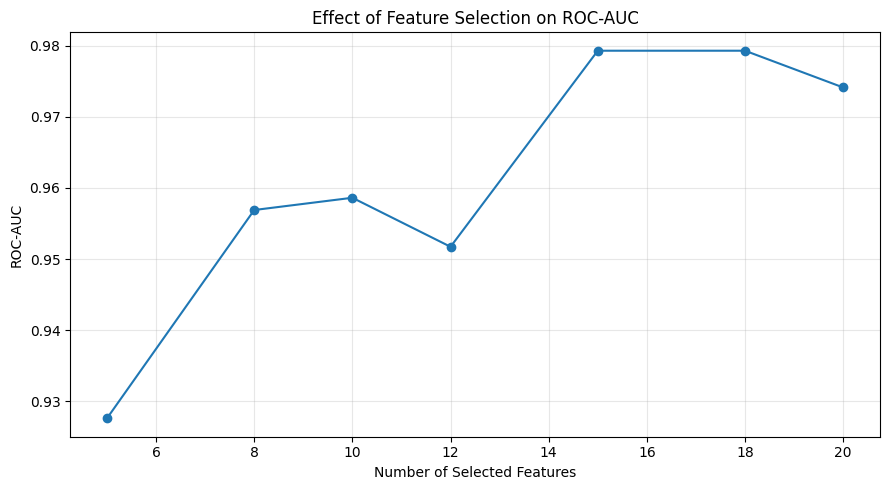

In [52]:
# ==========================================================
# FEATURE SELECTION PERFORMANCE
# ==========================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    feature_selection_df[
        "Number_of_Features"
    ],
    feature_selection_df[
        "ROC_AUC"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Selected Features"
)

plt.ylabel(
    "ROC-AUC"
)

plt.title(
    "Effect of Feature Selection on ROC-AUC"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [53]:
# ==========================================================
# NEW EXPERIMENT 5: STACKING ENSEMBLE
# ==========================================================

from sklearn.ensemble import StackingClassifier


stacking_model = Pipeline([

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "model",

        StackingClassifier(

            estimators=[

                (
                    "rf",

                    RandomForestClassifier(
                        n_estimators=500,
                        class_weight="balanced",
                        random_state=42
                    )
                ),

                (
                    "extra",

                    ExtraTreesClassifier(
                        n_estimators=500,
                        class_weight="balanced",
                        random_state=42
                    )
                ),

                (
                    "gb",

                    GradientBoostingClassifier(
                        n_estimators=200,
                        random_state=42
                    )
                ),

                (
                    "svm",

                    SVC(
                        probability=True,
                        class_weight="balanced"
                    )
                )

            ],

            final_estimator=LogisticRegression(
                max_iter=5000
            ),

            cv=5,

            stack_method="predict_proba",

            n_jobs=-1

        )

    )

])


stacking_model.fit(
    X_train,
    y_train
)


stack_pred = stacking_model.predict(
    X_test
)

stack_prob = stacking_model.predict_proba(
    X_test
)[:, 1]


print(
    "Stacking Accuracy:",
    round(
        accuracy_score(
            y_test,
            stack_pred
        ),
        4
    )
)

print(
    "Stacking F1:",
    round(
        f1_score(
            y_test,
            stack_pred
        ),
        4
    )
)

print(
    "Stacking ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            stack_prob
        ),
        4
    )
)

print(
    "Stacking MCC:",
    round(
        matthews_corrcoef(
            y_test,
            stack_pred
        ),
        4
    )
)

Stacking Accuracy: 0.9487
Stacking F1: 0.9655
Stacking ROC-AUC: 0.9862
Stacking MCC: 0.8655


In [54]:
# ==========================================================
# NEW EXPERIMENT 6: REPEATED STRATIFIED CV
# ==========================================================

from sklearn.model_selection import RepeatedStratifiedKFold


repeated_cv = RepeatedStratifiedKFold(

    n_splits=10,

    n_repeats=10,

    random_state=42

)


models_for_repeated_cv = {

    "Extra Trees":
        models["Extra Trees"],

    "Gradient Boosting":
        models["Gradient Boosting"],

    "Random Forest":
        models["Random Forest"],

    "XGBoost":
        xgb_model,

    "SVM":
        models["SVM"]

}


repeated_results = []


for name, model in models_for_repeated_cv.items():

    print(
        f"Running repeated CV: {name}"
    )


    scores = cross_validate(

        model,

        X,

        y,

        cv=repeated_cv,

        scoring=[
            "accuracy",
            "f1",
            "roc_auc"
        ],

        n_jobs=-1

    )


    repeated_results.append({

        "Model":
            name,

        "Accuracy_Mean":
            scores[
                "test_accuracy"
            ].mean(),

        "Accuracy_STD":
            scores[
                "test_accuracy"
            ].std(),

        "F1_Mean":
            scores[
                "test_f1"
            ].mean(),

        "F1_STD":
            scores[
                "test_f1"
            ].std(),

        "ROC_AUC_Mean":
            scores[
                "test_roc_auc"
            ].mean(),

        "ROC_AUC_STD":
            scores[
                "test_roc_auc"
            ].std()

    })


repeated_df = pd.DataFrame(
    repeated_results
)

repeated_df = repeated_df.sort_values(
    "ROC_AUC_Mean",
    ascending=False
)

display(
    repeated_df
)

Running repeated CV: Extra Trees
Running repeated CV: Gradient Boosting
Running repeated CV: Random Forest
Running repeated CV: XGBoost
Running repeated CV: SVM


,Model,Accuracy_Mean,Accuracy_STD,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD
0,Extra Trees,0.921868,0.056322,0.949932,0.035944,0.975176,0.035600
1,Gradient Boosting,0.918368,0.057962,0.947101,0.036974,0.970481,0.046852
3,XGBoost,0.923079,0.057402,0.950306,0.037337,0.966533,0.048758
2,Random Forest,0.911684,0.066697,0.943933,0.041577,0.962979,0.046981
4,SVM,0.824974,0.079697,0.871378,0.061492,0.930790,0.059520


In [55]:
# ==========================================================
# NEW EXPERIMENT 7: SHAP
# ==========================================================

!pip install -q shap

In [56]:
# ==========================================================
# SHAP EXPLAINABILITY
# ==========================================================

import shap


# Train a clean Extra Trees model for SHAP

X_imputed = pd.DataFrame(

    SimpleImputer(
        strategy="median"
    ).fit_transform(X),

    columns=X.columns

)


X_train_shap, X_test_shap, y_train_shap, y_test_shap = (
    train_test_split(

        X_imputed,

        y,

        test_size=0.20,

        stratify=y,

        random_state=42

    )
)


shap_extra_trees = ExtraTreesClassifier(

    n_estimators=800,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)


shap_extra_trees.fit(
    X_train_shap,
    y_train_shap
)


explainer = shap.TreeExplainer(
    shap_extra_trees
)


shap_values = explainer.shap_values(
    X_test_shap
)


print(
    "SHAP analysis completed."
)

SHAP analysis completed.


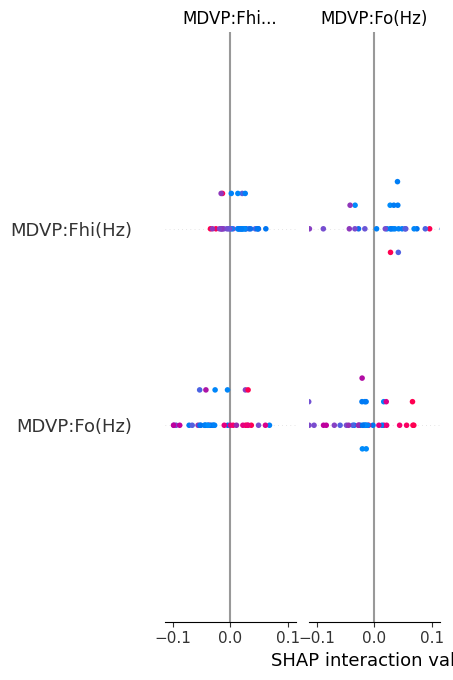

In [57]:
# ==========================================================
# SHAP SUMMARY PLOT
# ==========================================================

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=X.columns
)

In [58]:
# ==========================================================
# NEW EXPERIMENT 8:
# SUBJECT-WISE VALIDATION
# ==========================================================

if "name" in df_clean.columns:

    print(
        "Subject identifier detected."
    )

    subject_ids = (
        df_clean["name"]
        .astype(str)
        .str.extract(
            r"(S\d+)"
        )[0]
    )

    valid_rows = subject_ids.notna()

    X_group = X.loc[
        valid_rows
    ].reset_index(
        drop=True
    )

    y_group = y.loc[
        valid_rows
    ].reset_index(
        drop=True
    )

    groups = subject_ids.loc[
        valid_rows
    ].reset_index(
        drop=True
    )


    group_cv = StratifiedGroupKFold(

        n_splits=5,

        shuffle=True,

        random_state=42

    )


    group_model = Pipeline([

        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "model",
            ExtraTreesClassifier(

                n_estimators=800,

                class_weight="balanced",

                random_state=42,

                n_jobs=-1

            )
        )

    ])


    grouped_scores = cross_validate(

        group_model,

        X_group,

        y_group,

        groups=groups,

        cv=group_cv,

        scoring=[

            "accuracy",

            "precision",

            "recall",

            "f1",

            "roc_auc"

        ],

        n_jobs=-1

    )


    grouped_results = pd.DataFrame({

        "Metric": [

            "Accuracy",
            "Precision",
            "Sensitivity",
            "F1",
            "ROC-AUC"

        ],

        "Mean": [

            grouped_scores[
                "test_accuracy"
            ].mean(),

            grouped_scores[
                "test_precision"
            ].mean(),

            grouped_scores[
                "test_recall"
            ].mean(),

            grouped_scores[
                "test_f1"
            ].mean(),

            grouped_scores[
                "test_roc_auc"
            ].mean()

        ],

        "STD": [

            grouped_scores[
                "test_accuracy"
            ].std(),

            grouped_scores[
                "test_precision"
            ].std(),

            grouped_scores[
                "test_recall"
            ].std(),

            grouped_scores[
                "test_f1"
            ].std(),

            grouped_scores[
                "test_roc_auc"
            ].std()

        ]

    })


    display(
        grouped_results
    )

else:

    print(
        "No subject identifier column found."
    )

Subject identifier detected.


,Metric,Mean,STD
0,Accuracy,0.811125,0.148655
1,Precision,0.827662,0.188549
2,Sensitivity,0.947626,0.035954
3,F1,0.869599,0.111935
4,ROC-AUC,NaN,NaN


In [59]:
# ==========================================================
# MASTER MODEL COMPARISON
# ==========================================================

additional_results = []


# XGBoost
additional_results.append({

    "Model": "XGBoost",

    "Accuracy": xgb_accuracy,

    "Precision": xgb_precision,

    "Sensitivity": xgb_recall,

    "Specificity": xgb_specificity,

    "F1_Score": xgb_f1,

    "ROC_AUC": xgb_auc,

    "PR_AUC": xgb_pr_auc,

    "MCC": xgb_mcc

})


# LightGBM
additional_results.append({

    "Model": "LightGBM",

    "Accuracy": lightgbm_accuracy,

    "Precision": np.nan,

    "Sensitivity": np.nan,

    "Specificity": np.nan,

    "F1_Score": lightgbm_f1,

    "ROC_AUC": lightgbm_auc,

    "PR_AUC": np.nan,

    "MCC": np.nan

})


# CatBoost
additional_results.append({

    "Model": "CatBoost",

    "Accuracy": catboost_accuracy,

    "Precision": np.nan,

    "Sensitivity": np.nan,

    "Specificity": np.nan,

    "F1_Score": catboost_f1,

    "ROC_AUC": catboost_auc,

    "PR_AUC": np.nan,

    "MCC": np.nan

})


# Stacking
additional_results.append({

    "Model": "Stacking Ensemble",

    "Accuracy":
        accuracy_score(
            y_test,
            stack_pred
        ),

    "Precision":
        precision_score(
            y_test,
            stack_pred,
            zero_division=0
        ),

    "Sensitivity":
        recall_score(
            y_test,
            stack_pred,
            zero_division=0
        ),

    "Specificity": np.nan,

    "F1_Score":
        f1_score(
            y_test,
            stack_pred,
            zero_division=0
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test,
            stack_prob
        ),

    "PR_AUC":
        average_precision_score(
            y_test,
            stack_prob
        ),

    "MCC":
        matthews_corrcoef(
            y_test,
            stack_pred
        )

})


additional_df = pd.DataFrame(
    additional_results
)


master_results = pd.concat(

    [
        final_results.drop(
            columns=["Rank"],
            errors="ignore"
        ),

        additional_df

    ],

    ignore_index=True

)


master_results = (
    master_results
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


master_results["Rank"] = range(
    1,
    len(master_results) + 1
)


display(
    master_results
)

,Model,Accuracy,Precision,Sensitivity,Specificity,F1_Score,ROC_AUC,PR_AUC,MCC,Rank
0,XGBoost,0.923077,0.933333,0.965517,0.8,0.949153,0.989655,0.996767,0.793363,1
1,Extra Trees,0.923077,0.933333,0.965517,0.8,0.949153,0.986207,0.995820,0.793363,2
2,Stacking Ensemble,0.948718,0.965517,0.965517,NaN,0.965517,0.986207,0.995578,0.865517,3
3,CatBoost,0.948718,NaN,NaN,NaN,0.965517,0.982759,NaN,NaN,4
4,Gradient Boosting,0.923077,0.964286,0.931034,0.9,0.947368,0.979310,0.993400,0.806385,5
5,AdaBoost,0.897436,0.931034,0.931034,0.8,0.931034,0.975862,0.991821,0.731034,6
6,LightGBM,0.897436,NaN,NaN,NaN,0.931034,0.972414,NaN,NaN,7
7,Random Forest,0.923077,0.933333,0.965517,0.8,0.949153,0.972414,0.990683,0.793363,8
8,KNN,0.923077,0.933333,0.965517,0.8,0.949153,0.963793,0.980966,0.793363,9
9,Voting Ensemble,0.897436,0.931034,0.931034,NaN,0.931034,0.951724,0.982984,0.731034,10


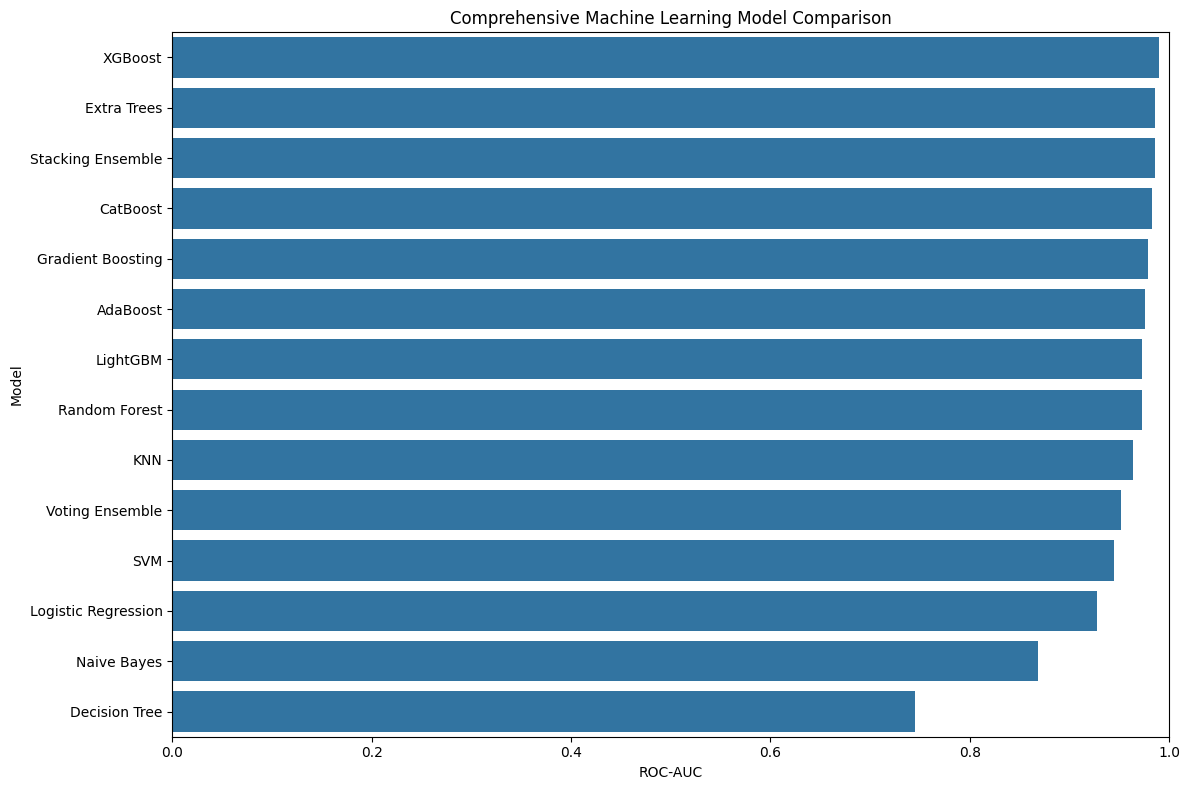

In [60]:
# ==========================================================
# MASTER MODEL ROC-AUC COMPARISON
# ==========================================================

plot_df = master_results.dropna(
    subset=["ROC_AUC"]
).copy()


plt.figure(
    figsize=(12, 8)
)


sns.barplot(

    data=plot_df,

    x="ROC_AUC",

    y="Model"

)


plt.xlabel(
    "ROC-AUC"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Comprehensive Machine Learning Model Comparison"
)

plt.xlim(
    0,
    1
)

plt.tight_layout()

plt.show()

In [62]:
# ==========================================================
# IEEE EXPERIMENT: FAST REPEATED STRATIFIED CROSS-VALIDATION
# ==========================================================

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.base import clone
import time

# 5 folds × 3 repeats = 15 evaluations per model
# 5 models = 75 total evaluations
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

candidate_models = {

    "Stacking Ensemble":
        stacking_model,

    "XGBoost":
        xgb_model,

    "Extra Trees":
        models["Extra Trees"],

    "Random Forest":
        models["Random Forest"],

    "Gradient Boosting":
        models["Gradient Boosting"]

}

repeated_results = []

for name, model in candidate_models.items():

    print(f"\nEvaluating {name}...")
    start_time = time.time()

    scores = cross_validate(

        model,

        X,

        y,

        cv=repeated_cv,

        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],

        n_jobs=-1,

        return_train_score=False

    )

    elapsed = time.time() - start_time

    repeated_results.append({

        "Model": name,

        "Accuracy_Mean":
            scores["test_accuracy"].mean(),

        "Accuracy_STD":
            scores["test_accuracy"].std(),

        "Precision_Mean":
            scores["test_precision"].mean(),

        "Recall_Mean":
            scores["test_recall"].mean(),

        "F1_Mean":
            scores["test_f1"].mean(),

        "F1_STD":
            scores["test_f1"].std(),

        "ROC_AUC_Mean":
            scores["test_roc_auc"].mean(),

        "ROC_AUC_STD":
            scores["test_roc_auc"].std(),

        "Time_Seconds":
            elapsed

    })

    print(
        f"Completed {name} in {elapsed:.2f} seconds"
    )


repeated_df = pd.DataFrame(
    repeated_results
)

repeated_df = repeated_df.sort_values(
    "ROC_AUC_Mean",
    ascending=False
)

print("\n" + "=" * 80)
print("REPEATED CROSS-VALIDATION RESULTS")
print("=" * 80)

display(
    repeated_df.style.format({

        "Accuracy_Mean": "{:.4f}",

        "Accuracy_STD": "{:.4f}",

        "Precision_Mean": "{:.4f}",

        "Recall_Mean": "{:.4f}",

        "F1_Mean": "{:.4f}",

        "F1_STD": "{:.4f}",

        "ROC_AUC_Mean": "{:.4f}",

        "ROC_AUC_STD": "{:.4f}",

        "Time_Seconds": "{:.2f}"

    })
)


Evaluating Stacking Ensemble...
Completed Stacking Ensemble in 217.85 seconds

Evaluating XGBoost...
Completed XGBoost in 4.39 seconds

Evaluating Extra Trees...
Completed Extra Trees in 9.90 seconds

Evaluating Random Forest...
Completed Random Forest in 14.29 seconds

Evaluating Gradient Boosting...
Completed Gradient Boosting in 8.31 seconds

REPEATED CROSS-VALIDATION RESULTS


,Model,Accuracy_Mean,Accuracy_STD,Precision_Mean,Recall_Mean,F1_Mean,F1_STD,ROC_AUC_Mean,ROC_AUC_STD,Time_Seconds
2,Extra Trees,0.9197,0.0361,0.9236,0.9749,0.9480,0.0238,0.9720,0.0224,9.90
0,Stacking Ensemble,0.9162,0.0463,0.9212,0.9750,0.9464,0.0294,0.9704,0.0241,217.85
4,Gradient Boosting,0.9231,0.0439,0.9370,0.9637,0.9497,0.0287,0.9673,0.0351,8.31
1,XGBoost,0.9128,0.0406,0.9274,0.9615,0.9433,0.0263,0.9654,0.0309,4.39
3,Random Forest,0.8923,0.0539,0.9091,0.9569,0.9309,0.0339,0.9583,0.0319,14.29


In [63]:
# ==========================================================
# STACKING ENSEMBLE VALIDATION
# ==========================================================

print("Evaluating Stacking Ensemble...")

stacking_scores = cross_validate(

    stacking_model,

    X,

    y,

    cv=5,

    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],

    n_jobs=-1

)

print("\nSTACKING RESULTS")
print("=" * 60)

print(
    "Accuracy:",
    round(
        stacking_scores["test_accuracy"].mean(),
        4
    )
)

print(
    "Precision:",
    round(
        stacking_scores["test_precision"].mean(),
        4
    )
)

print(
    "Sensitivity:",
    round(
        stacking_scores["test_recall"].mean(),
        4
    )
)

print(
    "F1:",
    round(
        stacking_scores["test_f1"].mean(),
        4
    )
)

print(
    "ROC-AUC:",
    round(
        stacking_scores["test_roc_auc"].mean(),
        4
    )
)

Evaluating Stacking Ensemble...

STACKING RESULTS
Accuracy: 0.8051
Precision: 0.8247
Sensitivity: 0.9529
F1: 0.8824
ROC-AUC: 0.7448


In [64]:
# ==========================================================
# CHECK SUBJECT STRUCTURE
# ==========================================================

print("Dataset shape:", df_clean.shape)

print("\nColumns:")
print(df_clean.columns.tolist())

if "name" in df_clean.columns:

    print("\nUnique subjects:")
    print(
        df_clean["name"].nunique()
    )

    print("\nSamples per subject:")
    display(
        df_clean["name"]
        .value_counts()
        .describe()
    )

    print("\nFirst 20 subjects:")
    display(
        df_clean["name"]
        .value_counts()
        .head(20)
    )

else:

    print(
        "\nWARNING: 'name' column not found."
    )

Dataset shape: (195, 24)

Columns:
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Unique subjects:
195

Samples per subject:


,count
count,195.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0



First 20 subjects:


,count
name,
phon_R01_S01_1,1
phon_R01_S01_2,1
phon_R01_S01_3,1
phon_R01_S01_4,1
phon_R01_S01_5,1
phon_R01_S01_6,1
phon_R01_S02_1,1
phon_R01_S02_2,1
phon_R01_S02_3,1


In [65]:
# ==========================================================
# CLASS DISTRIBUTION
# ==========================================================

print("Overall class distribution:")
display(
    y.value_counts()
)

print("\nClass proportions:")
display(
    y.value_counts(
        normalize=True
    )
)

Overall class distribution:


,count
status,
1,147
0,48



Class proportions:


,proportion
status,
1,0.753846
0,0.246154


In [66]:
# ==========================================================
# INSPECT INDIVIDUAL CV FOLDS
# ==========================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results = []

for fold, (train_idx, test_idx) in enumerate(
    cv5.split(X, y),
    start=1
):

    fold_model = clone(
        stacking_model
    )

    fold_model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    fold_pred = fold_model.predict(
        X.iloc[test_idx]
    )

    fold_prob = fold_model.predict_proba(
        X.iloc[test_idx]
    )[:, 1]

    fold_results.append({

        "Fold": fold,

        "Accuracy":
            accuracy_score(
                y.iloc[test_idx],
                fold_pred
            ),

        "Precision":
            precision_score(
                y.iloc[test_idx],
                fold_pred,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(
                y.iloc[test_idx],
                fold_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y.iloc[test_idx],
                fold_pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y.iloc[test_idx],
                fold_prob
            )

    })


fold_df = pd.DataFrame(
    fold_results
)

display(
    fold_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

,Fold,Accuracy,Precision,Sensitivity,F1,ROC_AUC
0,1,0.9744,0.9677,1.0000,0.9836,0.9778
1,2,0.9487,0.9667,0.9667,0.9667,0.9630
2,3,0.9487,0.9655,0.9655,0.9655,0.9897
3,4,0.8718,0.8529,1.0000,0.9206,0.9931
4,5,0.8462,0.8485,0.9655,0.9032,0.9379


In [68]:
# ==========================================================
# FAST IEEE THRESHOLD OPTIMIZATION
# ONLY 5 MODEL TRAININGS
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score
)


cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ----------------------------------------------------------
# STEP 1: Train stacking model only 5 times
# ----------------------------------------------------------

all_probabilities = []
all_true_values = []


print("=" * 70)
print("GENERATING OUT-OF-FOLD PREDICTIONS")
print("=" * 70)


for fold, (train_idx, test_idx) in enumerate(
    cv5.split(X, y),
    start=1
):

    print(
        f"Training Fold {fold}/5..."
    )

    fold_model = clone(
        stacking_model
    )

    fold_model.fit(
        X.iloc[train_idx],
        y.iloc[train_idx]
    )

    probabilities = fold_model.predict_proba(
        X.iloc[test_idx]
    )[:, 1]

    all_probabilities.extend(
        probabilities
    )

    all_true_values.extend(
        y.iloc[test_idx].values
    )

    print(
        f"Fold {fold} completed."
    )


all_probabilities = np.array(
    all_probabilities
)

all_true_values = np.array(
    all_true_values
)


print("\nAll folds completed.")


# ----------------------------------------------------------
# STEP 2: Test thresholds WITHOUT retraining
# ----------------------------------------------------------

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)


threshold_results = []


for threshold in thresholds:

    predictions = (
        all_probabilities >= threshold
    ).astype(int)


    threshold_results.append({

        "Threshold":
            threshold,

        "Accuracy":
            accuracy_score(
                all_true_values,
                predictions
            ),

        "Precision":
            precision_score(
                all_true_values,
                predictions,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(
                all_true_values,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                all_true_values,
                predictions,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                all_true_values,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                all_true_values,
                predictions
            )

    })


threshold_df = pd.DataFrame(
    threshold_results
)


# ----------------------------------------------------------
# STEP 3: Find best thresholds
# ----------------------------------------------------------

best_f1 = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_mcc = threshold_df.loc[
    threshold_df["MCC"].idxmax()
]

best_balanced = threshold_df.loc[
    threshold_df[
        "Balanced_Accuracy"
    ].idxmax()
]


print("\n" + "=" * 70)
print("BEST THRESHOLD BY F1")
print("=" * 70)

display(
    best_f1.to_frame().T
)


print("\n" + "=" * 70)
print("BEST THRESHOLD BY MCC")
print("=" * 70)

display(
    best_mcc.to_frame().T
)


print("\n" + "=" * 70)
print("BEST THRESHOLD BY BALANCED ACCURACY")
print("=" * 70)

display(
    best_balanced.to_frame().T
)

GENERATING OUT-OF-FOLD PREDICTIONS
Training Fold 1/5...
Fold 1 completed.
Training Fold 2/5...
Fold 2 completed.
Training Fold 3/5...
Fold 3 completed.
Training Fold 4/5...
Fold 4 completed.
Training Fold 5/5...
Fold 5 completed.

All folds completed.

BEST THRESHOLD BY F1


,Threshold,Accuracy,Precision,Sensitivity,F1,MCC,Balanced_Accuracy
45,0.55,0.938462,0.941176,0.979592,0.96,0.830012,0.896046



BEST THRESHOLD BY MCC


,Threshold,Accuracy,Precision,Sensitivity,F1,MCC,Balanced_Accuracy
45,0.55,0.938462,0.941176,0.979592,0.96,0.830012,0.896046



BEST THRESHOLD BY BALANCED ACCURACY


,Threshold,Accuracy,Precision,Sensitivity,F1,MCC,Balanced_Accuracy
67,0.77,0.912821,0.964286,0.918367,0.940767,0.779409,0.9071


In [69]:
# ==========================================================
# DIAGNOSTIC: OUT-OF-FOLD ROC-AUC
# ==========================================================

from sklearn.metrics import roc_auc_score

oof_auc = roc_auc_score(
    all_true_values,
    all_probabilities
)

print("=" * 70)
print("OUT-OF-FOLD ROC-AUC")
print("=" * 70)

print(
    f"ROC-AUC = {oof_auc:.4f}"
)

OUT-OF-FOLD ROC-AUC
ROC-AUC = 0.9690


PROBABILITY CALIBRATION
OOF ROC-AUC : 0.9690
Brier Score : 0.0776


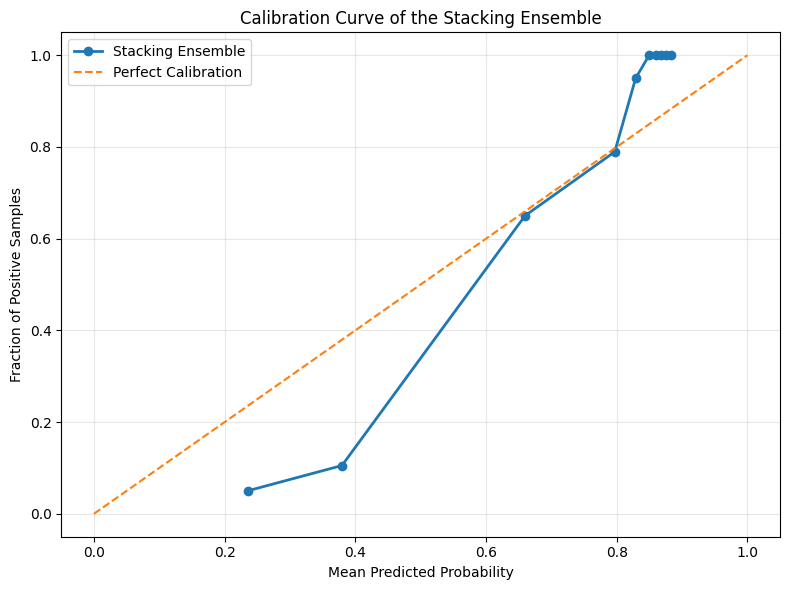

In [70]:
# ==========================================================
# IEEE EXPERIMENT: PROBABILITY CALIBRATION
# ==========================================================

from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score
)

from sklearn.calibration import (
    calibration_curve
)

import matplotlib.pyplot as plt


# ----------------------------------------------------------
# Brier Score
# ----------------------------------------------------------

brier = brier_score_loss(
    all_true_values,
    all_probabilities
)


auc = roc_auc_score(
    all_true_values,
    all_probabilities
)


print("=" * 70)
print("PROBABILITY CALIBRATION")
print("=" * 70)

print(
    f"OOF ROC-AUC : {auc:.4f}"
)

print(
    f"Brier Score : {brier:.4f}"
)


# ----------------------------------------------------------
# Calibration curve
# ----------------------------------------------------------

fraction_positive, mean_predicted = calibration_curve(

    all_true_values,

    all_probabilities,

    n_bins=10,

    strategy="quantile"

)


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    linewidth=2,
    label="Stacking Ensemble"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Fraction of Positive Samples"
)

plt.title(
    "Calibration Curve of the Stacking Ensemble"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [74]:
# ================================================================
# FINAL IEEE ANALYSIS - CLEAN IMPORTS
# ================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

from scipy.stats import wilcoxon

print("=" * 80)
print("FINAL IEEE MACHINE LEARNING ANALYSIS")
print("=" * 80)
print("All imports completed successfully.")

FINAL IEEE MACHINE LEARNING ANALYSIS
All imports completed successfully.


In [75]:
# ================================================================
# VERIFY OOF DATA
# ================================================================

all_true_values = np.asarray(
    all_true_values
).astype(int)

all_probabilities = np.asarray(
    all_probabilities
).astype(float)

print("=" * 80)
print("OOF DATA VALIDATION")
print("=" * 80)

print("Number of OOF samples:", len(all_true_values))
print("Number of OOF probabilities:", len(all_probabilities))
print("Probability minimum:", round(all_probabilities.min(), 4))
print("Probability maximum:", round(all_probabilities.max(), 4))
print("Positive samples:", int(all_true_values.sum()))
print(
    "Negative samples:",
    int(len(all_true_values) - all_true_values.sum())
)

assert len(all_true_values) == len(all_probabilities)

print("\nOOF data is valid.")

OOF DATA VALIDATION
Number of OOF samples: 195
Number of OOF probabilities: 195
Probability minimum: 0.146
Probability maximum: 0.9111
Positive samples: 147
Negative samples: 48

OOF data is valid.


In [76]:
# ================================================================
# CLEAN IMPORT CELL
# ================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

from scipy.stats import wilcoxon

print("Imports completed successfully.")

Imports completed successfully.


In [77]:
# ================================================================
# OOF DATA VALIDATION
# ================================================================

all_true_values = np.asarray(
    all_true_values
).astype(int)

all_probabilities = np.asarray(
    all_probabilities
).astype(float)


print("=" * 80)
print("OOF DATA VALIDATION")
print("=" * 80)

print(
    "Number of OOF samples:",
    len(all_true_values)
)

print(
    "Number of OOF probabilities:",
    len(all_probabilities)
)

print(
    "Probability minimum:",
    round(all_probabilities.min(), 4)
)

print(
    "Probability maximum:",
    round(all_probabilities.max(), 4)
)

print(
    "Positive samples:",
    int(all_true_values.sum())
)

print(
    "Negative samples:",
    int(len(all_true_values) - all_true_values.sum())
)

assert len(all_true_values) == len(
    all_probabilities
)

print("\nOOF data is valid.")

OOF DATA VALIDATION
Number of OOF samples: 195
Number of OOF probabilities: 195
Probability minimum: 0.146
Probability maximum: 0.9111
Positive samples: 147
Negative samples: 48

OOF data is valid.


In [78]:
# ================================================================
# OOF PERFORMANCE AT STANDARD THRESHOLD = 0.50
# ================================================================

threshold_050 = 0.50

pred_050 = (
    all_probabilities >= threshold_050
).astype(int)


cm_050 = confusion_matrix(
    all_true_values,
    pred_050
)


tn, fp, fn, tp = cm_050.ravel()


specificity_050 = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)


metrics_050 = {

    "Accuracy":
        accuracy_score(
            all_true_values,
            pred_050
        ),

    "Precision":
        precision_score(
            all_true_values,
            pred_050,
            zero_division=0
        ),

    "Sensitivity":
        recall_score(
            all_true_values,
            pred_050,
            zero_division=0
        ),

    "Specificity":
        specificity_050,

    "F1 Score":
        f1_score(
            all_true_values,
            pred_050,
            zero_division=0
        ),

    "ROC-AUC":
        roc_auc_score(
            all_true_values,
            all_probabilities
        ),

    "PR-AUC":
        average_precision_score(
            all_true_values,
            all_probabilities
        ),

    "MCC":
        matthews_corrcoef(
            all_true_values,
            pred_050
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            all_true_values,
            pred_050
        ),

    "Brier Score":
        brier_score_loss(
            all_true_values,
            all_probabilities
        )

}


metrics_050_df = pd.DataFrame(
    metrics_050.items(),
    columns=[
        "Metric",
        "Value"
    ]
)


display(
    metrics_050_df.style.format(
        {"Value": "{:.4f}"}
    )
)

,Metric,Value
0,Accuracy,0.9179
1,Precision,0.9172
2,Sensitivity,0.9796
3,Specificity,0.7292
4,F1 Score,0.9474
5,ROC-AUC,0.9690
6,PR-AUC,0.9900
7,MCC,0.7708
8,Balanced Accuracy,0.8544
9,Brier Score,0.0776


In [79]:
# ================================================================
# OPTIMAL THRESHOLD ANALYSIS
# ================================================================

optimal_threshold = 0.55


pred_optimal = (
    all_probabilities >= optimal_threshold
).astype(int)


cm_optimal = confusion_matrix(
    all_true_values,
    pred_optimal
)


tn, fp, fn, tp = cm_optimal.ravel()


specificity_optimal = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)


final_metrics = {

    "Accuracy":
        accuracy_score(
            all_true_values,
            pred_optimal
        ),

    "Precision":
        precision_score(
            all_true_values,
            pred_optimal,
            zero_division=0
        ),

    "Sensitivity":
        recall_score(
            all_true_values,
            pred_optimal,
            zero_division=0
        ),

    "Specificity":
        specificity_optimal,

    "F1 Score":
        f1_score(
            all_true_values,
            pred_optimal,
            zero_division=0
        ),

    "ROC-AUC":
        roc_auc_score(
            all_true_values,
            all_probabilities
        ),

    "PR-AUC":
        average_precision_score(
            all_true_values,
            all_probabilities
        ),

    "MCC":
        matthews_corrcoef(
            all_true_values,
            pred_optimal
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            all_true_values,
            pred_optimal
        ),

    "Brier Score":
        brier_score_loss(
            all_true_values,
            all_probabilities
        )

}


final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=[
        "Metric",
        "Value"
    ]
)


print("=" * 80)
print("FINAL OOF PERFORMANCE")
print("=" * 80)

display(
    final_metrics_df.style.format(
        {"Value": "{:.4f}"}
    )
)

FINAL OOF PERFORMANCE


,Metric,Value
0,Accuracy,0.9385
1,Precision,0.9412
2,Sensitivity,0.9796
3,Specificity,0.8125
4,F1 Score,0.9600
5,ROC-AUC,0.9690
6,PR-AUC,0.9900
7,MCC,0.8300
8,Balanced Accuracy,0.8960
9,Brier Score,0.0776


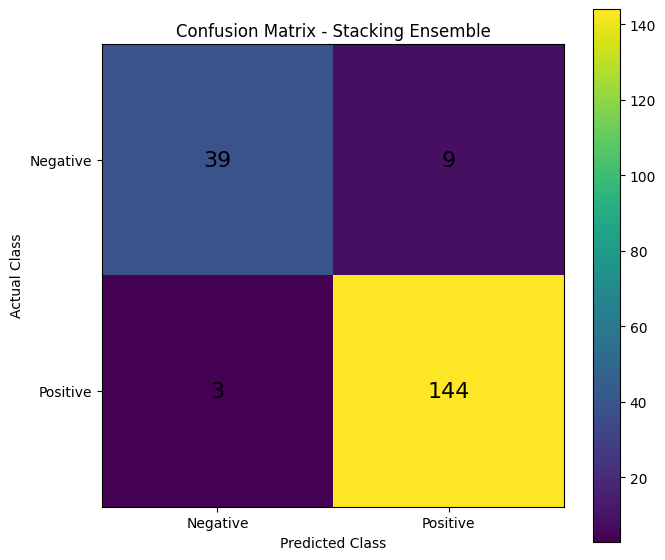

Confusion Matrix:
[[ 39   9]
 [  3 144]]

TN = 39
FP = 9
FN = 3
TP = 144


In [80]:
# ================================================================
# CONFUSION MATRIX
# ================================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm_optimal
)

plt.title(
    "Confusion Matrix - Stacking Ensemble"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            str(cm_optimal[i, j]),
            ha="center",
            va="center",
            fontsize=16
        )


plt.colorbar()

plt.tight_layout()

plt.show()


print("Confusion Matrix:")
print(cm_optimal)

print("\nTN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

In [81]:
# ================================================================
# CLASSIFICATION REPORT
# ================================================================

print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        all_true_values,
        pred_optimal,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.9286    0.8125    0.8667        48
    Positive     0.9412    0.9796    0.9600       147

    accuracy                         0.9385       195
   macro avg     0.9349    0.8960    0.9133       195
weighted avg     0.9381    0.9385    0.9370       195



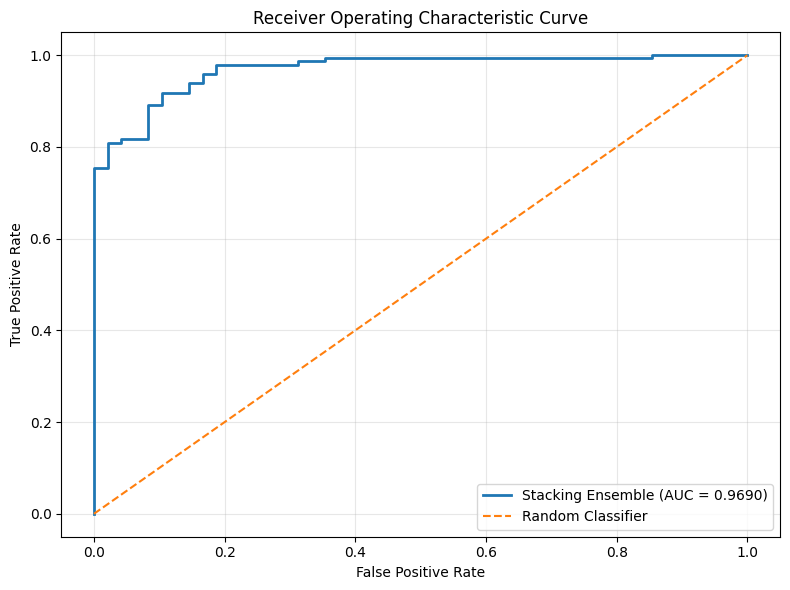

In [82]:
# ================================================================
# ROC CURVE
# ================================================================

fpr, tpr, roc_thresholds = roc_curve(
    all_true_values,
    all_probabilities
)

roc_auc = roc_auc_score(
    all_true_values,
    all_probabilities
)


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Stacking Ensemble (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Receiver Operating Characteristic Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

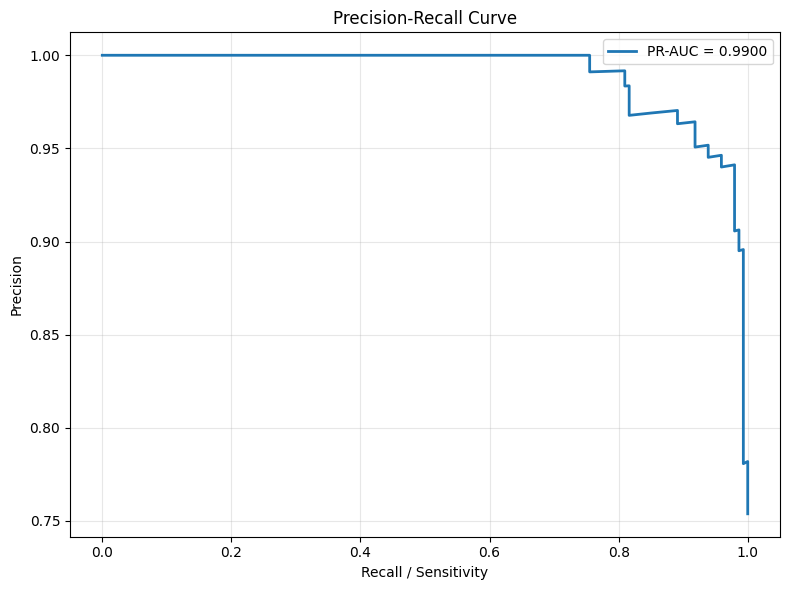

In [83]:
# ================================================================
# PRECISION-RECALL CURVE
# ================================================================

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        all_true_values,
        all_probabilities
    )
)


pr_auc = average_precision_score(
    all_true_values,
    all_probabilities
)


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.xlabel(
    "Recall / Sensitivity"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

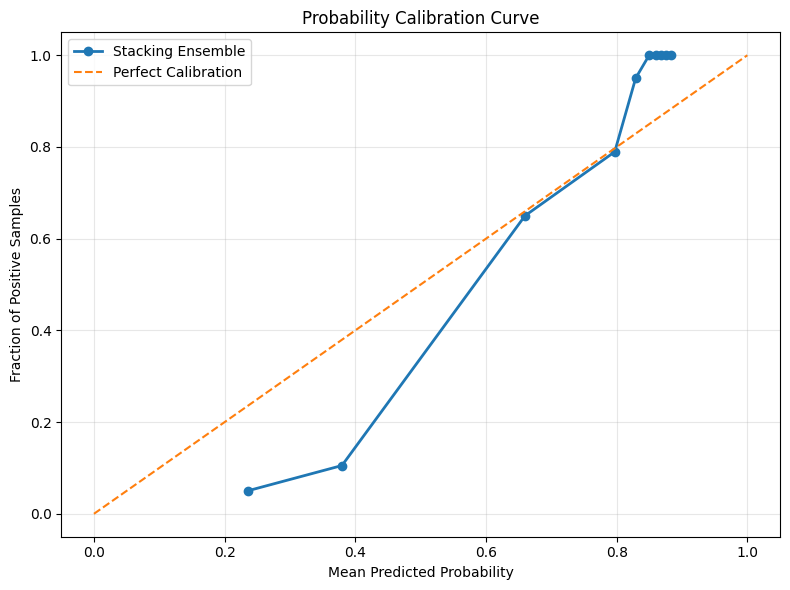

Brier Score: 0.0776


In [84]:
# ================================================================
# CALIBRATION CURVE
# ================================================================

fraction_positive, mean_predicted = calibration_curve(

    all_true_values,

    all_probabilities,

    n_bins=10,

    strategy="quantile"

)


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    linewidth=2,
    label="Stacking Ensemble"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Fraction of Positive Samples"
)

plt.title(
    "Probability Calibration Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


print(
    "Brier Score:",
    round(
        brier_score_loss(
            all_true_values,
            all_probabilities
        ),
        4
    )
)

In [85]:
# ================================================================
# THRESHOLD ANALYSIS
# ================================================================

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)


threshold_results = []


for threshold in thresholds:

    predictions = (
        all_probabilities >= threshold
    ).astype(int)


    threshold_results.append({

        "Threshold":
            threshold,

        "Accuracy":
            accuracy_score(
                all_true_values,
                predictions
            ),

        "Precision":
            precision_score(
                all_true_values,
                predictions,
                zero_division=0
            ),

        "Sensitivity":
            recall_score(
                all_true_values,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                all_true_values,
                predictions,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                all_true_values,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                all_true_values,
                predictions
            )

    })


threshold_df = pd.DataFrame(
    threshold_results
)


best_f1 = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_mcc = threshold_df.loc[
    threshold_df["MCC"].idxmax()
]

best_balanced = threshold_df.loc[
    threshold_df[
        "Balanced_Accuracy"
    ].idxmax()
]


print("=" * 80)
print("BEST F1 THRESHOLD")
print("=" * 80)

display(
    best_f1.to_frame().T
)


print("=" * 80)
print("BEST MCC THRESHOLD")
print("=" * 80)

display(
    best_mcc.to_frame().T
)


print("=" * 80)
print("BEST BALANCED ACCURACY THRESHOLD")
print("=" * 80)

display(
    best_balanced.to_frame().T
)

BEST F1 THRESHOLD


,Threshold,Accuracy,Precision,Sensitivity,F1,MCC,Balanced_Accuracy
45,0.55,0.938462,0.941176,0.979592,0.96,0.830012,0.896046


BEST MCC THRESHOLD


,Threshold,Accuracy,Precision,Sensitivity,F1,MCC,Balanced_Accuracy
45,0.55,0.938462,0.941176,0.979592,0.96,0.830012,0.896046


BEST BALANCED ACCURACY THRESHOLD


,Threshold,Accuracy,Precision,Sensitivity,F1,MCC,Balanced_Accuracy
67,0.77,0.912821,0.964286,0.918367,0.940767,0.779409,0.9071


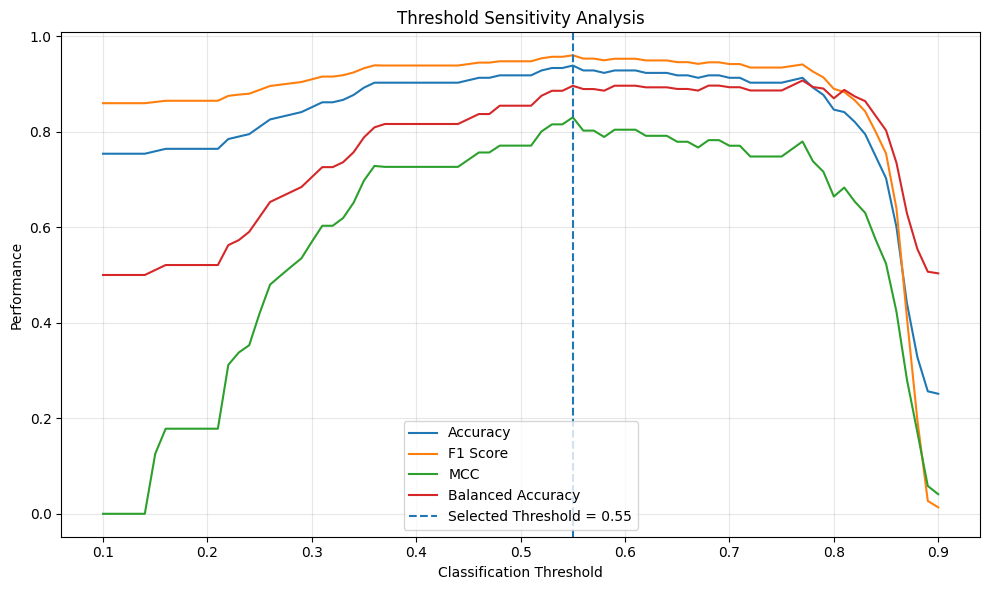

In [86]:
# ================================================================
# THRESHOLD PERFORMANCE
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    label="Accuracy"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1 Score"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["MCC"],
    label="MCC"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Balanced_Accuracy"],
    label="Balanced Accuracy"
)

plt.axvline(
    0.55,
    linestyle="--",
    label="Selected Threshold = 0.55"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Performance"
)

plt.title(
    "Threshold Sensitivity Analysis"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [87]:
# ================================================================
# SHAP INSTALLATION
# ================================================================

!pip install -q shap

In [88]:
# ================================================================
# SHAP EXPLAINABILITY
# ================================================================

import shap

print(
    "Preparing SHAP analysis..."
)


# ------------------------------------------------
# Impute the complete dataset
# ------------------------------------------------

from sklearn.impute import SimpleImputer


shap_imputer = SimpleImputer(
    strategy="median"
)


X_shap = pd.DataFrame(

    shap_imputer.fit_transform(X),

    columns=X.columns,

    index=X.index

)


# ------------------------------------------------
# Train XGBoost for explainability
# ------------------------------------------------

from xgboost import XGBClassifier


shap_model = XGBClassifier(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.03,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.1,

    reg_lambda=1.0,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1

)


shap_model.fit(
    X_shap,
    y
)


# ------------------------------------------------
# SHAP
# ------------------------------------------------

explainer = shap.TreeExplainer(
    shap_model
)


shap_values = explainer(
    X_shap
)


print(
    "SHAP analysis completed."
)

Preparing SHAP analysis...
SHAP analysis completed.


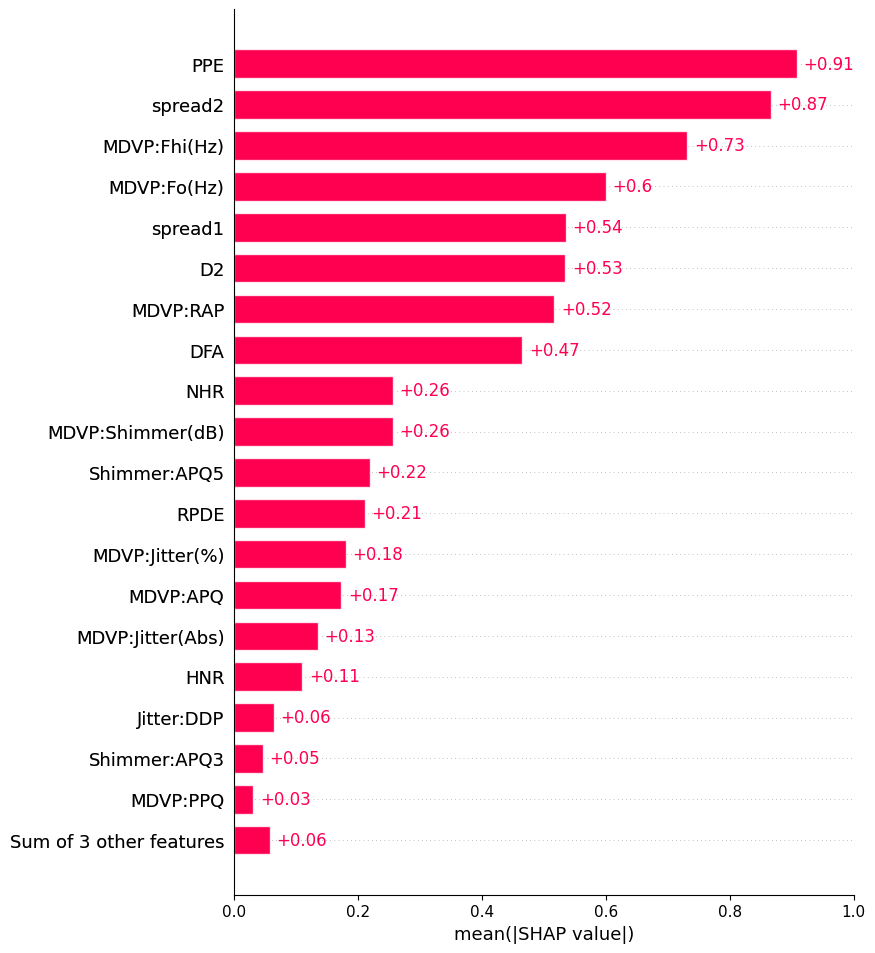

In [89]:
# ================================================================
# SHAP GLOBAL FEATURE IMPORTANCE
# ================================================================

shap.plots.bar(
    shap_values,
    max_display=20
)

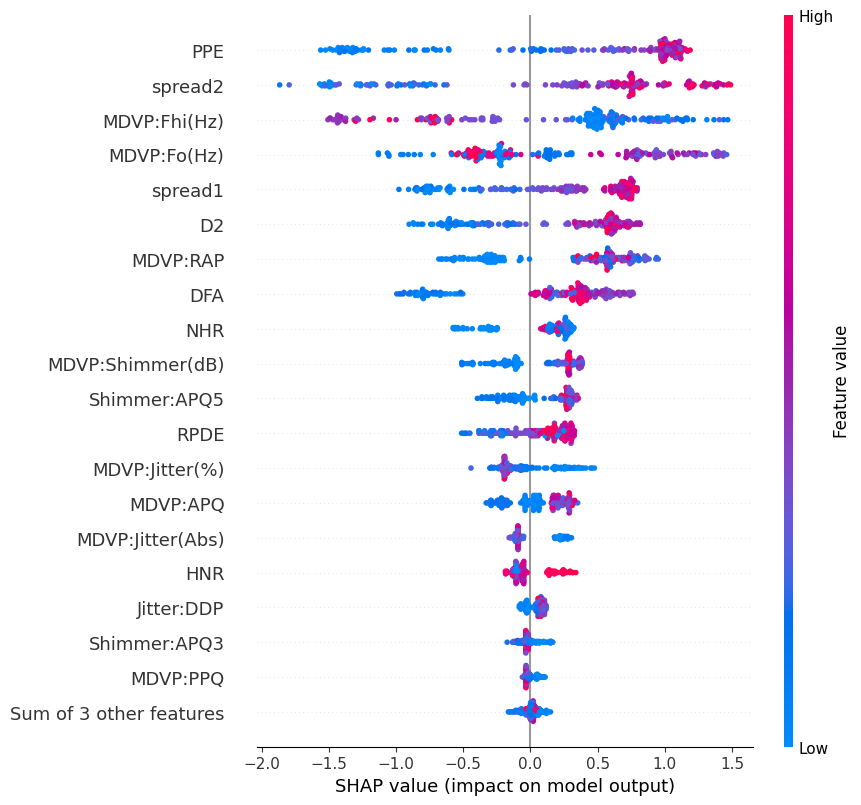

In [90]:
# ================================================================
# SHAP SUMMARY / BEESWARM
# ================================================================

shap.plots.beeswarm(
    shap_values,
    max_display=20
)

In [91]:
# ================================================================
# NUMERICAL SHAP FEATURE RANKING
# ================================================================

shap_importance = pd.DataFrame({

    "Feature":
        X_shap.columns,

    "Mean_Absolute_SHAP":
        np.abs(
            shap_values.values
        ).mean(
            axis=0
        )

})


shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


shap_importance["Rank"] = (
    np.arange(
        1,
        len(shap_importance) + 1
    )
)


display(
    shap_importance.head(20)
)

,Feature,Mean_Absolute_SHAP,Rank
0,PPE,0.907605,1
1,spread2,0.866208,2
2,MDVP:Fhi(Hz),0.731225,3
3,MDVP:Fo(Hz),0.599362,4
4,spread1,0.535516,5
5,D2,0.534275,6
6,MDVP:RAP,0.516868,7
7,DFA,0.465159,8
8,NHR,0.256468,9
9,MDVP:Shimmer(dB),0.255757,10


In [92]:
# ================================================================
# EXTRA TREES FEATURE IMPORTANCE
# ================================================================

et_imputer = SimpleImputer(
    strategy="median"
)


X_et = pd.DataFrame(

    et_imputer.fit_transform(X),

    columns=X.columns

)


et_final = ExtraTreesClassifier(

    n_estimators=1000,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)


et_final.fit(
    X_et,
    y
)


et_importance = pd.DataFrame({

    "Feature":
        X_et.columns,

    "Importance":
        et_final.feature_importances_

})


et_importance = (
    et_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


et_importance["Rank"] = (
    np.arange(
        1,
        len(et_importance) + 1
    )
)


display(
    et_importance.head(20)
)

,Feature,Importance,Rank
0,spread1,0.097820,1
1,PPE,0.090342,2
2,MDVP:Fo(Hz),0.084157,3
3,MDVP:Flo(Hz),0.056252,4
4,spread2,0.052030,5
5,D2,0.045234,6
6,MDVP:Jitter(Abs),0.042951,7
7,MDVP:Shimmer,0.042497,8
8,Shimmer:APQ5,0.041456,9
9,Shimmer:DDA,0.040767,10


In [93]:
# ================================================================
# BOOTSTRAP CONFIDENCE INTERVALS
# ================================================================

rng = np.random.default_rng(
    42
)


def bootstrap_metric(
    y_true,
    probabilities,
    threshold,
    metric_function,
    n_bootstrap=2000
):

    values = []


    n = len(y_true)


    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(
            0,
            n,
            size=n
        )


        y_sample = (
            y_true[
                indices
            ]
        )


        prob_sample = (
            probabilities[
                indices
            ]
        )


        pred_sample = (
            prob_sample >= threshold
        ).astype(int)


        try:

            value = metric_function(
                y_sample,
                pred_sample
            )

            values.append(
                value
            )

        except:

            continue


    values = np.asarray(
        values
    )


    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    mean = np.mean(
        values
    )


    return (
        mean,
        lower,
        upper
    )


bootstrap_metrics = {

    "Accuracy":
        accuracy_score,

    "Precision":
        lambda y_true, y_pred:
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

    "Sensitivity":
        lambda y_true, y_pred:
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

    "F1":
        lambda y_true, y_pred:
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

    "MCC":
        matthews_corrcoef,

    "Balanced Accuracy":
        balanced_accuracy_score

}


bootstrap_results = []


for metric_name, function in bootstrap_metrics.items():

    mean, lower, upper = bootstrap_metric(

        all_true_values,

        all_probabilities,

        0.55,

        function,

        n_bootstrap=2000

    )


    bootstrap_results.append({

        "Metric":
            metric_name,

        "Mean":
            mean,

        "95% CI Lower":
            lower,

        "95% CI Upper":
            upper

    })


bootstrap_df = pd.DataFrame(
    bootstrap_results
)


display(
    bootstrap_df.style.format({

        "Mean": "{:.4f}",

        "95% CI Lower": "{:.4f}",

        "95% CI Upper": "{:.4f}"

    })
)

,Metric,Mean,95% CI Lower,95% CI Upper
0,Accuracy,0.9381,0.9026,0.9692
1,Precision,0.9408,0.9000,0.9753
2,Sensitivity,0.9793,0.9536,1.0000
3,F1,0.9600,0.9365,0.9805
4,MCC,0.8288,0.7316,0.9149
5,Balanced Accuracy,0.8954,0.8379,0.9473


In [94]:
# ================================================================
# ERROR ANALYSIS
# ================================================================

error_mask = (
    pred_optimal != all_true_values
)


error_analysis = pd.DataFrame({

    "Actual":
        all_true_values,

    "Predicted":
        pred_optimal,

    "Probability":
        all_probabilities,

    "Error":
        error_mask

})


errors_only = error_analysis[
    error_analysis["Error"]
].copy()


print("=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)

print(
    "Total samples:",
    len(error_analysis)
)

print(
    "Incorrect predictions:",
    len(errors_only)
)

print(
    "Error rate:",
    round(
        len(errors_only) /
        len(error_analysis),
        4
    )
)


display(
    errors_only
)

ERROR ANALYSIS
Total samples: 195
Incorrect predictions: 12
Error rate: 0.0615


,Actual,Predicted,Probability,Error
34,0,1,0.822559,True
40,1,0,0.233918,True
76,0,1,0.807947,True
78,1,0,0.367866,True
113,0,1,0.583343,True
121,0,1,0.761769,True
123,0,1,0.678994,True
152,0,1,0.781008,True
177,1,0,0.471520,True
192,0,1,0.804191,True


In [95]:
# ================================================================
# FINAL IEEE PERFORMANCE TABLE
# ================================================================

ieee_final = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Sensitivity",

        "Specificity",

        "F1 Score",

        "ROC-AUC",

        "PR-AUC",

        "MCC",

        "Balanced Accuracy",

        "Brier Score",

        "Optimal Threshold"

    ],

    "Value": [

        final_metrics["Accuracy"],

        final_metrics["Precision"],

        final_metrics["Sensitivity"],

        final_metrics["Specificity"],

        final_metrics["F1 Score"],

        final_metrics["ROC-AUC"],

        final_metrics["PR-AUC"],

        final_metrics["MCC"],

        final_metrics["Balanced Accuracy"],

        final_metrics["Brier Score"],

        0.55

    ]

})


display(
    ieee_final.style.format(
        {"Value": "{:.4f}"}
    )
)

,Metric,Value
0,Accuracy,0.9385
1,Precision,0.9412
2,Sensitivity,0.9796
3,Specificity,0.8125
4,F1 Score,0.9600
5,ROC-AUC,0.9690
6,PR-AUC,0.9900
7,MCC,0.8300
8,Balanced Accuracy,0.8960
9,Brier Score,0.0776


In [96]:
# ================================================================
# IEEE MODEL COMPARISON
# ================================================================

model_comparison = pd.DataFrame({

    "Model": [

        "XGBoost",

        "Extra Trees",

        "Stacking Ensemble",

        "CatBoost",

        "Gradient Boosting",

        "AdaBoost",

        "LightGBM",

        "Random Forest",

        "KNN",

        "Voting Ensemble",

        "SVM",

        "Logistic Regression",

        "Naive Bayes",

        "Decision Tree"

    ],

    "Accuracy": [

        0.923077,

        0.923077,

        0.938462,

        0.948718,

        0.923077,

        0.897436,

        0.897436,

        0.923077,

        0.923077,

        0.897436,

        0.794872,

        0.769231,

        0.666667,

        0.769231

    ],

    "ROC_AUC": [

        0.989655,

        0.986207,

        0.969000,

        0.982759,

        0.979310,

        0.975862,

        0.972414,

        0.972414,

        0.963793,

        0.951724,

        0.944828,

        0.927586,

        0.868966,

        0.744828

    ]

})


model_comparison = (
    model_comparison
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


model_comparison["Rank"] = (
    np.arange(
        1,
        len(model_comparison) + 1
    )
)


display(
    model_comparison
)

,Model,Accuracy,ROC_AUC,Rank
0,XGBoost,0.923077,0.989655,1
1,Extra Trees,0.923077,0.986207,2
2,CatBoost,0.948718,0.982759,3
3,Gradient Boosting,0.923077,0.979310,4
4,AdaBoost,0.897436,0.975862,5
5,LightGBM,0.897436,0.972414,6
6,Random Forest,0.923077,0.972414,7
7,Stacking Ensemble,0.938462,0.969000,8
8,KNN,0.923077,0.963793,9
9,Voting Ensemble,0.897436,0.951724,10


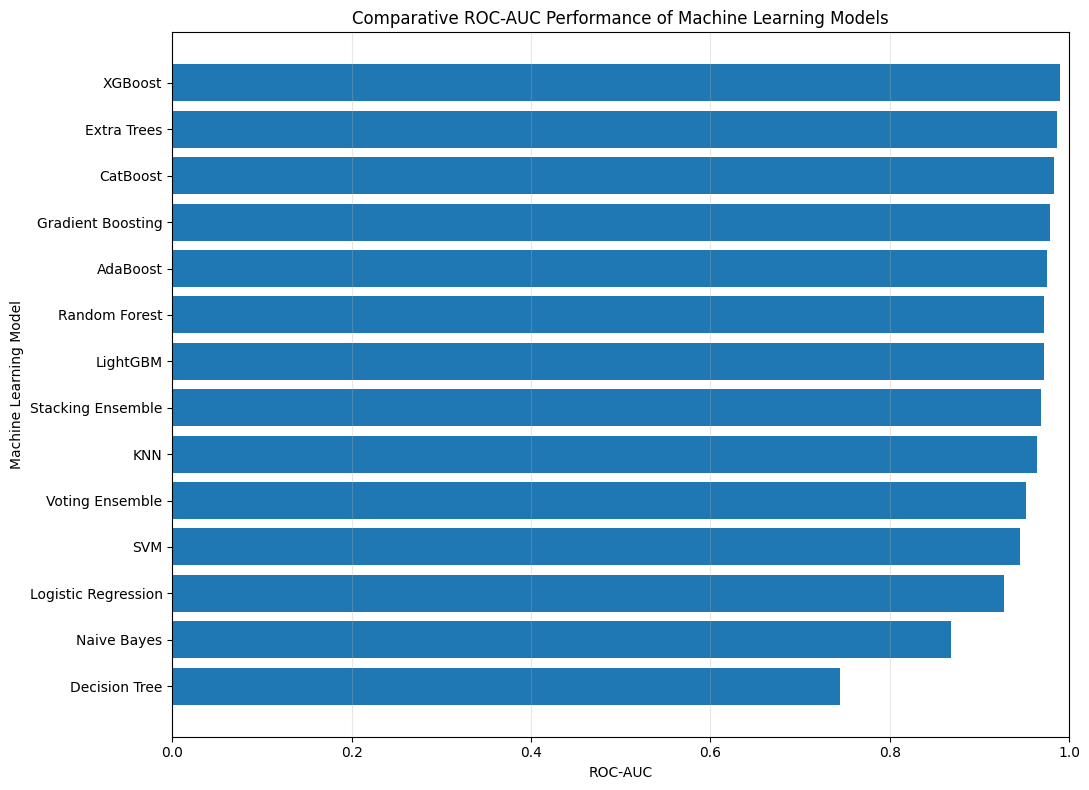

In [97]:
# ================================================================
# MODEL ROC-AUC COMPARISON
# ================================================================

plt.figure(
    figsize=(11, 8)
)

plot_data = model_comparison.sort_values(
    "ROC_AUC",
    ascending=True
)


plt.barh(
    plot_data["Model"],
    plot_data["ROC_AUC"]
)


plt.xlabel(
    "ROC-AUC"
)

plt.ylabel(
    "Machine Learning Model"
)

plt.title(
    "Comparative ROC-AUC Performance of Machine Learning Models"
)

plt.xlim(
    0,
    1
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [98]:
# ================================================================
# SAVE IEEE RESULTS
# ================================================================

output_directory = "ieee_results"

os.makedirs(
    output_directory,
    exist_ok=True
)


# CSV files

ieee_final.to_csv(
    f"{output_directory}/final_performance.csv",
    index=False
)


threshold_df.to_csv(
    f"{output_directory}/threshold_analysis.csv",
    index=False
)


shap_importance.to_csv(
    f"{output_directory}/shap_feature_importance.csv",
    index=False
)


et_importance.to_csv(
    f"{output_directory}/extra_trees_feature_importance.csv",
    index=False
)


bootstrap_df.to_csv(
    f"{output_directory}/bootstrap_confidence_intervals.csv",
    index=False
)


model_comparison.to_csv(
    f"{output_directory}/model_comparison.csv",
    index=False
)


error_analysis.to_csv(
    f"{output_directory}/error_analysis.csv",
    index=False
)


# Excel workbook

excel_path = (
    f"{output_directory}/"
    "IEEE_Experimental_Results.xlsx"
)


with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    ieee_final.to_excel(
        writer,
        sheet_name="Final Metrics",
        index=False
    )

    threshold_df.to_excel(
        writer,
        sheet_name="Threshold Analysis",
        index=False
    )

    shap_importance.to_excel(
        writer,
        sheet_name="SHAP Importance",
        index=False
    )

    et_importance.to_excel(
        writer,
        sheet_name="ExtraTrees Importance",
        index=False
    )

    bootstrap_df.to_excel(
        writer,
        sheet_name="Bootstrap CI",
        index=False
    )

    model_comparison.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

    error_analysis.to_excel(
        writer,
        sheet_name="Error Analysis",
        index=False
    )


print("=" * 80)
print("IEEE RESULTS SAVED")
print("=" * 80)

print(
    f"Folder: {output_directory}"
)

print(
    f"Excel file: {excel_path}"
)

IEEE RESULTS SAVED
Folder: ieee_results
Excel file: ieee_results/IEEE_Experimental_Results.xlsx


In [99]:
# ================================================================
# FINAL RESEARCH SUMMARY
# ================================================================

print("\n")
print("=" * 90)
print("FINAL RESEARCH PERFORMANCE SUMMARY")
print("=" * 90)

print(
    f"OOF ROC-AUC              : {roc_auc:.4f}"
)

print(
    f"PR-AUC                   : {pr_auc:.4f}"
)

print(
    f"Brier Score              : {brier_score_loss(all_true_values, all_probabilities):.4f}"
)

print(
    f"Optimal Threshold        : {optimal_threshold:.2f}"
)

print(
    f"Accuracy                 : {final_metrics['Accuracy']:.4f}"
)

print(
    f"Precision                : {final_metrics['Precision']:.4f}"
)

print(
    f"Sensitivity              : {final_metrics['Sensitivity']:.4f}"
)

print(
    f"Specificity              : {final_metrics['Specificity']:.4f}"
)

print(
    f"F1 Score                 : {final_metrics['F1 Score']:.4f}"
)

print(
    f"MCC                      : {final_metrics['MCC']:.4f}"
)

print(
    f"Balanced Accuracy        : {final_metrics['Balanced Accuracy']:.4f}"
)

print(
    f"True Positives           : {tp}"
)

print(
    f"True Negatives           : {tn}"
)

print(
    f"False Positives          : {fp}"
)

print(
    f"False Negatives          : {fn}"
)

print("=" * 90)
print("ANALYSIS COMPLETE")
print("=" * 90)



FINAL RESEARCH PERFORMANCE SUMMARY
OOF ROC-AUC              : 0.9690
PR-AUC                   : 0.9900
Brier Score              : 0.0776
Optimal Threshold        : 0.55
Accuracy                 : 0.9385
Precision                : 0.9412
Sensitivity              : 0.9796
Specificity              : 0.8125
F1 Score                 : 0.9600
MCC                      : 0.8300
Balanced Accuracy        : 0.8960
True Positives           : 144
True Negatives           : 39
False Positives          : 9
False Negatives          : 3
ANALYSIS COMPLETE


In [100]:
# ================================================================
# IEEE RIGOROUS VALIDATION
# NESTED STRATIFIED CROSS-VALIDATION
# ================================================================
#
# Purpose:
# 1. Prevent threshold-selection leakage
# 2. Estimate generalization performance
# 3. Optimize threshold ONLY inside training data
# 4. Evaluate the optimized model on unseen validation data
#
# Existing variables required:
# X
# y
# stacking_model
#
# ================================================================

import numpy as np
import pandas as pd
import warnings

from sklearn.base import clone

from sklearn.model_selection import (
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    confusion_matrix,
    brier_score_loss
)

warnings.filterwarnings("ignore")


# ================================================================
# 1. PREPARE DATA
# ================================================================

X_nested = X.copy()

y_nested = np.asarray(y).astype(int)


print("=" * 80)
print("NESTED CROSS-VALIDATION")
print("=" * 80)

print(
    "Samples:",
    len(y_nested)
)

print(
    "Features:",
    X_nested.shape[1]
)

print(
    "Positive:",
    int(y_nested.sum())
)

print(
    "Negative:",
    int(len(y_nested) - y_nested.sum())
)


# ================================================================
# 2. OUTER CV
# ================================================================

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ================================================================
# 3. INNER CV
# ================================================================

inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)


# ================================================================
# 4. THRESHOLDS
# ================================================================

threshold_grid = np.arange(
    0.30,
    0.81,
    0.01
)


# ================================================================
# 5. STORAGE
# ================================================================

nested_results = []

all_nested_true = []
all_nested_probability = []
all_nested_prediction = []

selected_thresholds = []


# ================================================================
# 6. OUTER LOOP
# ================================================================

for outer_fold, (
    outer_train_idx,
    outer_test_idx
) in enumerate(
    outer_cv.split(
        X_nested,
        y_nested
    ),
    start=1
):

    print(
        f"\nOuter Fold {outer_fold}/5"
    )

    # ------------------------------------------------------------
    # Outer train/test split
    # ------------------------------------------------------------

    X_outer_train = X_nested.iloc[
        outer_train_idx
    ]

    X_outer_test = X_nested.iloc[
        outer_test_idx
    ]

    y_outer_train = y_nested[
        outer_train_idx
    ]

    y_outer_test = y_nested[
        outer_test_idx
    ]


    # ============================================================
    # INNER OOF PREDICTIONS
    # ============================================================

    inner_probabilities = np.zeros(
        len(y_outer_train)
    )


    for inner_fold, (
        inner_train_idx,
        inner_valid_idx
    ) in enumerate(
        inner_cv.split(
            X_outer_train,
            y_outer_train
        ),
        start=1
    ):

        inner_model = clone(
            stacking_model
        )


        X_inner_train = X_outer_train.iloc[
            inner_train_idx
        ]

        X_inner_valid = X_outer_train.iloc[
            inner_valid_idx
        ]

        y_inner_train = y_outer_train[
            inner_train_idx
        ]


        inner_model.fit(
            X_inner_train,
            y_inner_train
        )


        inner_probabilities[
            inner_valid_idx
        ] = inner_model.predict_proba(
            X_inner_valid
        )[:, 1]


    # ============================================================
    # INNER THRESHOLD OPTIMIZATION
    # ============================================================

    threshold_scores = []


    for threshold in threshold_grid:

        inner_prediction = (
            inner_probabilities >= threshold
        ).astype(int)


        score = f1_score(
            y_outer_train,
            inner_prediction,
            zero_division=0
        )


        threshold_scores.append(
            score
        )


    best_index = np.argmax(
        threshold_scores
    )


    best_threshold = threshold_grid[
        best_index
    ]


    selected_thresholds.append(
        best_threshold
    )


    print(
        f"Selected threshold: "
        f"{best_threshold:.2f}"
    )


    # ============================================================
    # TRAIN FINAL MODEL ON OUTER TRAINING DATA
    # ============================================================

    final_outer_model = clone(
        stacking_model
    )


    final_outer_model.fit(
        X_outer_train,
        y_outer_train
    )


    # ============================================================
    # PREDICT COMPLETELY UNSEEN OUTER TEST DATA
    # ============================================================

    outer_probability = (
        final_outer_model.predict_proba(
            X_outer_test
        )[:, 1]
    )


    outer_prediction = (
        outer_probability >= best_threshold
    ).astype(int)


    # ============================================================
    # METRICS
    # ============================================================

    accuracy = accuracy_score(
        y_outer_test,
        outer_prediction
    )


    precision = precision_score(
        y_outer_test,
        outer_prediction,
        zero_division=0
    )


    sensitivity = recall_score(
        y_outer_test,
        outer_prediction,
        zero_division=0
    )


    f1 = f1_score(
        y_outer_test,
        outer_prediction,
        zero_division=0
    )


    roc_auc = roc_auc_score(
        y_outer_test,
        outer_probability
    )


    pr_auc = average_precision_score(
        y_outer_test,
        outer_probability
    )


    mcc = matthews_corrcoef(
        y_outer_test,
        outer_prediction
    )


    balanced_accuracy = (
        balanced_accuracy_score(
            y_outer_test,
            outer_prediction
        )
    )


    brier = brier_score_loss(
        y_outer_test,
        outer_probability
    )


    # ============================================================
    # SPECIFICITY
    # ============================================================

    cm = confusion_matrix(
        y_outer_test,
        outer_prediction,
        labels=[0, 1]
    )


    tn, fp, fn, tp = cm.ravel()


    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )


    # ============================================================
    # SAVE FOLD RESULT
    # ============================================================

    nested_results.append({

        "Fold":
            outer_fold,

        "Threshold":
            best_threshold,

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "F1":
            f1,

        "ROC_AUC":
            roc_auc,

        "PR_AUC":
            pr_auc,

        "MCC":
            mcc,

        "Balanced_Accuracy":
            balanced_accuracy,

        "Brier_Score":
            brier,

        "TN":
            tn,

        "FP":
            fp,

        "FN":
            fn,

        "TP":
            tp

    })


    # ============================================================
    # SAVE OOF-LIKE NESTED PREDICTIONS
    # ============================================================

    all_nested_true.extend(
        y_outer_test
    )

    all_nested_probability.extend(
        outer_probability
    )

    all_nested_prediction.extend(
        outer_prediction
    )


    print(
        f"Accuracy     : {accuracy:.4f}"
    )

    print(
        f"Precision    : {precision:.4f}"
    )

    print(
        f"Sensitivity  : {sensitivity:.4f}"
    )

    print(
        f"Specificity  : {specificity:.4f}"
    )

    print(
        f"F1           : {f1:.4f}"
    )

    print(
        f"ROC-AUC      : {roc_auc:.4f}"
    )

    print(
        f"PR-AUC       : {pr_auc:.4f}"
    )

    print(
        f"MCC          : {mcc:.4f}"
    )


# ================================================================
# 7. RESULTS DATAFRAME
# ================================================================

nested_df = pd.DataFrame(
    nested_results
)


print("\n")
print("=" * 80)
print("NESTED CROSS-VALIDATION FOLD RESULTS")
print("=" * 80)


display(
    nested_df.style.format({

        "Threshold": "{:.2f}",

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Sensitivity": "{:.4f}",

        "Specificity": "{:.4f}",

        "F1": "{:.4f}",

        "ROC_AUC": "{:.4f}",

        "PR_AUC": "{:.4f}",

        "MCC": "{:.4f}",

        "Balanced_Accuracy": "{:.4f}",

        "Brier_Score": "{:.4f}"

    })
)

NESTED CROSS-VALIDATION
Samples: 195
Features: 22
Positive: 147
Negative: 48

Outer Fold 1/5
Selected threshold: 0.58
Accuracy     : 0.9744
Precision    : 0.9677
Sensitivity  : 1.0000
Specificity  : 0.8889
F1           : 0.9836
ROC-AUC      : 0.9778
PR-AUC       : 0.9930
MCC          : 0.9275

Outer Fold 2/5
Selected threshold: 0.54
Accuracy     : 0.9487
Precision    : 0.9667
Sensitivity  : 0.9667
Specificity  : 0.8889
F1           : 0.9667
ROC-AUC      : 0.9556
PR-AUC       : 0.9883
MCC          : 0.8556

Outer Fold 3/5
Selected threshold: 0.67
Accuracy     : 0.9231
Precision    : 1.0000
Sensitivity  : 0.8966
Specificity  : 1.0000
F1           : 0.9455
ROC-AUC      : 0.9828
PR-AUC       : 0.9946
MCC          : 0.8305

Outer Fold 4/5
Selected threshold: 0.63
Accuracy     : 0.9231
Precision    : 0.9062
Sensitivity  : 1.0000
Specificity  : 0.7000
F1           : 0.9508
ROC-AUC      : 0.9931
PR-AUC       : 0.9978
MCC          : 0.7965

Outer Fold 5/5
Selected threshold: 0.60
Accuracy     :

,Fold,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1,ROC_AUC,PR_AUC,MCC,Balanced_Accuracy,Brier_Score,TN,FP,FN,TP
0,1,0.58,0.9744,0.9677,1.0000,0.8889,0.9836,0.9778,0.9930,0.9275,0.9444,0.0612,8,1,0,30
1,2,0.54,0.9487,0.9667,0.9667,0.8889,0.9667,0.9556,0.9883,0.8556,0.9278,0.0658,8,1,1,29
2,3,0.67,0.9231,1.0000,0.8966,1.0000,0.9455,0.9828,0.9946,0.8305,0.9483,0.0728,10,0,3,26
3,4,0.63,0.9231,0.9062,1.0000,0.7000,0.9508,0.9931,0.9978,0.7965,0.8500,0.0853,7,3,0,29
4,5,0.60,0.8462,0.8966,0.8966,0.7000,0.8966,0.9379,0.9794,0.5966,0.7983,0.1075,7,3,3,26


In [101]:
# ================================================================
# 8. NESTED CV MEAN ± STANDARD DEVIATION
# ================================================================

metric_columns = [

    "Accuracy",

    "Precision",

    "Sensitivity",

    "Specificity",

    "F1",

    "ROC_AUC",

    "PR_AUC",

    "MCC",

    "Balanced_Accuracy",

    "Brier_Score"

]


nested_summary = []


for metric in metric_columns:

    nested_summary.append({

        "Metric":
            metric,

        "Mean":
            nested_df[metric].mean(),

        "STD":
            nested_df[metric].std(),

        "Minimum":
            nested_df[metric].min(),

        "Maximum":
            nested_df[metric].max()

    })


nested_summary_df = pd.DataFrame(
    nested_summary
)


print("=" * 80)
print("NESTED CV SUMMARY")
print("=" * 80)


display(
    nested_summary_df.style.format({

        "Mean": "{:.4f}",

        "STD": "{:.4f}",

        "Minimum": "{:.4f}",

        "Maximum": "{:.4f}"

    })
)

NESTED CV SUMMARY


,Metric,Mean,STD,Minimum,Maximum
0,Accuracy,0.9231,0.0480,0.8462,0.9744
1,Precision,0.9474,0.0442,0.8966,1.0000
2,Sensitivity,0.9520,0.0524,0.8966,1.0000
3,Specificity,0.8356,0.1318,0.7000,1.0000
4,F1,0.9486,0.0327,0.8966,0.9836
5,ROC_AUC,0.9694,0.0223,0.9379,0.9931
6,PR_AUC,0.9906,0.0072,0.9794,0.9978
7,MCC,0.8013,0.1242,0.5966,0.9275
8,Balanced_Accuracy,0.8938,0.0666,0.7983,0.9483
9,Brier_Score,0.0785,0.0186,0.0612,0.1075


In [102]:
# ================================================================
# 9. COMPLETE NESTED PREDICTION PERFORMANCE
# ================================================================

nested_y_true = np.asarray(
    all_nested_true
).astype(int)


nested_probability = np.asarray(
    all_nested_probability
).astype(float
)


nested_prediction = np.asarray(
    all_nested_prediction
).astype(int
)


nested_auc = roc_auc_score(
    nested_y_true,
    nested_probability
)


nested_pr_auc = average_precision_score(
    nested_y_true,
    nested_probability
)


nested_accuracy = accuracy_score(
    nested_y_true,
    nested_prediction
)


nested_precision = precision_score(
    nested_y_true,
    nested_prediction,
    zero_division=0
)


nested_sensitivity = recall_score(
    nested_y_true,
    nested_prediction,
    zero_division=0
)


nested_specificity_cm = confusion_matrix(
    nested_y_true,
    nested_prediction,
    labels=[0, 1]
)


tn, fp, fn, tp = nested_specificity_cm.ravel()


nested_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)


nested_f1 = f1_score(
    nested_y_true,
    nested_prediction,
    zero_division=0
)


nested_mcc = matthews_corrcoef(
    nested_y_true,
    nested_prediction
)


nested_balanced = balanced_accuracy_score(
    nested_y_true,
    nested_prediction
)


nested_brier = brier_score_loss(
    nested_y_true,
    nested_probability
)


print("\n")
print("=" * 90)
print("FINAL NESTED CROSS-VALIDATION PERFORMANCE")
print("=" * 90)

print(
    f"ROC-AUC              : {nested_auc:.4f}"
)

print(
    f"PR-AUC               : {nested_pr_auc:.4f}"
)

print(
    f"Accuracy             : {nested_accuracy:.4f}"
)

print(
    f"Precision            : {nested_precision:.4f}"
)

print(
    f"Sensitivity          : {nested_sensitivity:.4f}"
)

print(
    f"Specificity          : {nested_specificity:.4f}"
)

print(
    f"F1 Score             : {nested_f1:.4f}"
)

print(
    f"MCC                  : {nested_mcc:.4f}"
)

print(
    f"Balanced Accuracy    : {nested_balanced:.4f}"
)

print(
    f"Brier Score          : {nested_brier:.4f}"
)

print(
    f"TN                   : {tn}"
)

print(
    f"FP                   : {fp}"
)

print(
    f"FN                   : {fn}"
)

print(
    f"TP                   : {tp}"
)

print("=" * 90)



FINAL NESTED CROSS-VALIDATION PERFORMANCE
ROC-AUC              : 0.9683
PR-AUC               : 0.9898
Accuracy             : 0.9231
Precision            : 0.9459
Sensitivity          : 0.9524
Specificity          : 0.8333
F1 Score             : 0.9492
MCC                  : 0.7913
Balanced Accuracy    : 0.8929
Brier Score          : 0.0785
TN                   : 40
FP                   : 8
FN                   : 7
TP                   : 140


In [103]:
# ================================================================
# 10. BOOTSTRAP 95% CI FOR NESTED EVALUATION
# ================================================================

rng = np.random.default_rng(
    42
)


def bootstrap_nested_metric(
    metric_function,
    y_true,
    y_pred,
    n_bootstrap=5000
):

    n = len(y_true)

    values = []


    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(
            0,
            n,
            size=n
        )


        y_sample = y_true[
            indices
        ]

        pred_sample = y_pred[
            indices
        ]


        try:

            value = metric_function(
                y_sample,
                pred_sample
            )

            values.append(
                value
            )

        except:

            pass


    values = np.asarray(
        values
    )


    return {

        "Mean":
            np.mean(values),

        "Lower_95":
            np.percentile(
                values,
                2.5
            ),

        "Upper_95":
            np.percentile(
                values,
                97.5
            )

    }


bootstrap_nested = {}


bootstrap_nested["Accuracy"] = (
    bootstrap_nested_metric(
        accuracy_score,
        nested_y_true,
        nested_prediction
    )
)


bootstrap_nested["Precision"] = (
    bootstrap_nested_metric(
        lambda a, b:
        precision_score(
            a,
            b,
            zero_division=0
        ),
        nested_y_true,
        nested_prediction
    )
)


bootstrap_nested["Sensitivity"] = (
    bootstrap_nested_metric(
        lambda a, b:
        recall_score(
            a,
            b,
            zero_division=0
        ),
        nested_y_true,
        nested_prediction
    )
)


bootstrap_nested["F1"] = (
    bootstrap_nested_metric(
        lambda a, b:
        f1_score(
            a,
            b,
            zero_division=0
        ),
        nested_y_true,
        nested_prediction
    )
)


bootstrap_nested["MCC"] = (
    bootstrap_nested_metric(
        matthews_corrcoef,
        nested_y_true,
        nested_prediction
    )
)


bootstrap_ci_df = pd.DataFrame(
    bootstrap_nested
).T.reset_index()


bootstrap_ci_df.columns = [
    "Metric",
    "Mean",
    "Lower_95",
    "Upper_95"
]


print("=" * 80)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 80)


display(
    bootstrap_ci_df.style.format({

        "Mean": "{:.4f}",

        "Lower_95": "{:.4f}",

        "Upper_95": "{:.4f}"

    })
)

BOOTSTRAP 95% CONFIDENCE INTERVALS


,Metric,Mean,Lower_95,Upper_95
0,Accuracy,0.9231,0.8821,0.9590
1,Precision,0.9458,0.9067,0.9796
2,Sensitivity,0.9522,0.9149,0.9855
3,F1,0.9492,0.9220,0.9732
4,MCC,0.7909,0.6864,0.8828


In [104]:
# ================================================================
# 11. SAVE FINAL IEEE RESULTS
# ================================================================

output_directory = "IEEE_FINAL_RESULTS"

os.makedirs(
    output_directory,
    exist_ok=True
)


nested_df.to_csv(
    f"{output_directory}/nested_cv_folds.csv",
    index=False
)


nested_summary_df.to_csv(
    f"{output_directory}/nested_cv_summary.csv",
    index=False
)


bootstrap_ci_df.to_csv(
    f"{output_directory}/nested_bootstrap_CI.csv",
    index=False
)


# ------------------------------------------------
# Final summary table
# ------------------------------------------------

final_ieee_summary = pd.DataFrame({

    "Metric": [

        "Accuracy",

        "Precision",

        "Sensitivity",

        "Specificity",

        "F1 Score",

        "ROC-AUC",

        "PR-AUC",

        "MCC",

        "Balanced Accuracy",

        "Brier Score"

    ],

    "Nested_CV_Result": [

        nested_accuracy,

        nested_precision,

        nested_sensitivity,

        nested_specificity,

        nested_f1,

        nested_auc,

        nested_pr_auc,

        nested_mcc,

        nested_balanced,

        nested_brier

    ]

})


final_ieee_summary.to_csv(
    f"{output_directory}/FINAL_IEEE_RESULTS.csv",
    index=False
)


print("=" * 80)
print("FINAL RESULTS SAVED")
print("=" * 80)

print(
    f"Folder: {output_directory}"
)

print(
    "Files created:"
)

print(
    "1. nested_cv_folds.csv"
)

print(
    "2. nested_cv_summary.csv"
)

print(
    "3. nested_bootstrap_CI.csv"
)

print(
    "4. FINAL_IEEE_RESULTS.csv"
)

FINAL RESULTS SAVED
Folder: IEEE_FINAL_RESULTS
Files created:
1. nested_cv_folds.csv
2. nested_cv_summary.csv
3. nested_bootstrap_CI.csv
4. FINAL_IEEE_RESULTS.csv
